I will build 4 variations:
* Custom networks (at least 3) to show that you explored hyperparameters a bit.
* Transfer learning (at least 2, e.g., VGG, Inception V3, ResNet50).
* Data augmentation with custom network (only 1 network is enough, the one that previously gave the best results).
* Data augmentation with transfer learning (the above 2+ networks).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import kagglehub
import os
from PIL import Image
import imageio

# Import Data

In [2]:


path = kagglehub.dataset_download("luisolazo/tomato-diseases")


print("Path to dataset files:", path)


100%|██████████| 411M/411M [00:05<00:00, 82.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/luisolazo/tomato-diseases/versions/3


In [3]:
dataset_path = path

In [4]:

print(os.listdir(dataset_path))

['train', 'test']


In [5]:
labels=os.listdir(dataset_path+'/train')
print(labels)

['healthy', 'twospotted_spider_mite', 'septoria_leaf_spot', 'yellow_leaf_curl_virus', 'late_blight', 'early_blight', 'mosaic_virus', 'bacterial_spot', 'leaf_mold', 'target_spot']


# Data Preprocessing

In [6]:
test_labels=os.listdir(dataset_path+'/test')

In [7]:
for label in labels:
  print(label,len(os.listdir(dataset_path+'/train/'+label)))

healthy 1883
twospotted_spider_mite 1232
septoria_leaf_spot 1327
yellow_leaf_curl_virus 3595
late_blight 2093
early_blight 2177
mosaic_virus 1197
bacterial_spot 1679
leaf_mold 1460
target_spot 1110


In [8]:
for label in labels:
  print(f"The {label} has, {len(os.listdir(dataset_path+'/train/'+label))} samples in the train folder")

The healthy has, 1883 samples in the train folder
The twospotted_spider_mite has, 1232 samples in the train folder
The septoria_leaf_spot has, 1327 samples in the train folder
The yellow_leaf_curl_virus has, 3595 samples in the train folder
The late_blight has, 2093 samples in the train folder
The early_blight has, 2177 samples in the train folder
The mosaic_virus has, 1197 samples in the train folder
The bacterial_spot has, 1679 samples in the train folder
The leaf_mold has, 1460 samples in the train folder
The target_spot has, 1110 samples in the train folder


In [9]:
count=[]
names=[]
for label in labels:
  count.append(len(os.listdir(dataset_path+'/train/'+label)))
  names.append(label)
df=pd.DataFrame({'Disease':names,'Count':count})

/tmp/ipython-input-2948546487.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Disease',y='Count',data=df,order=df.sort_values('Count',ascending=False).Disease,palette='Blues_r')


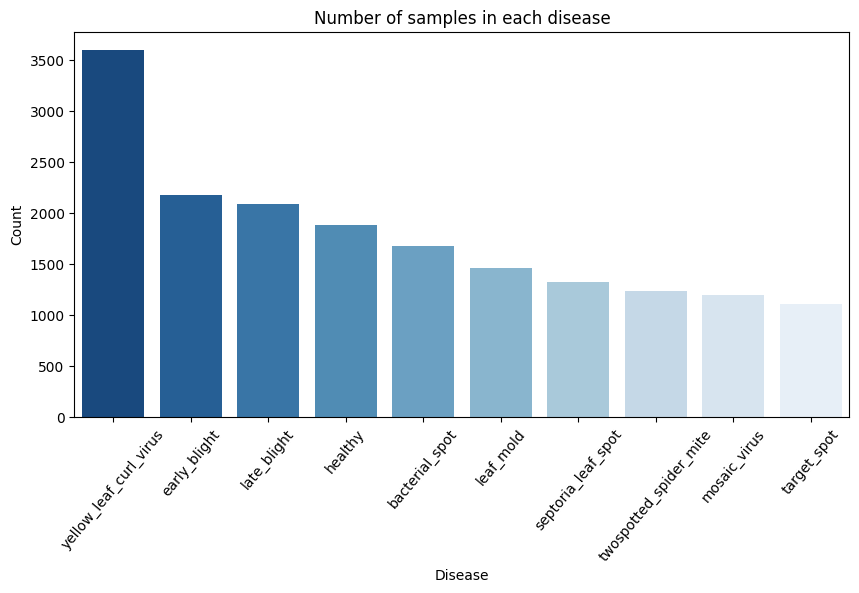

In [10]:
plt.figure(figsize=(10,5))
sns.barplot(x='Disease',y='Count',data=df,order=df.sort_values('Count',ascending=False).Disease,palette='Blues_r')
plt.title('Number of samples in each disease')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.xticks(rotation=50)
plt.show()

* Our dataset is highly imbalanced; we will address this issue later in the data augmentation section.

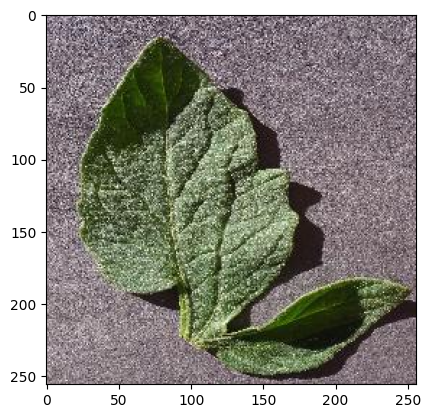

In [11]:
path_of=os.listdir(dataset_path+'/train/healthy')
image=plt.imread(dataset_path+'/train/healthy/'+path_of[1])
plt.imshow(image)

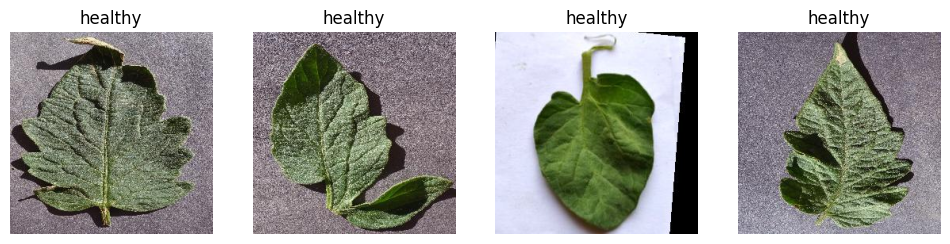

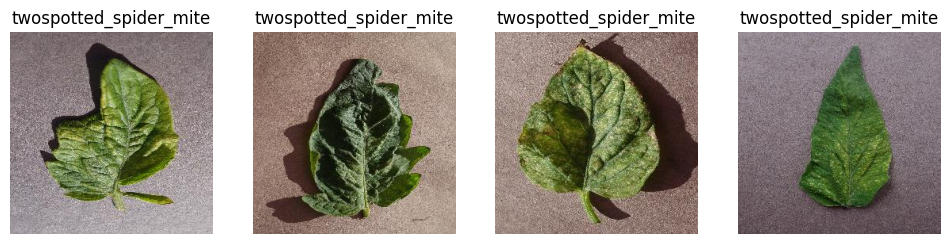

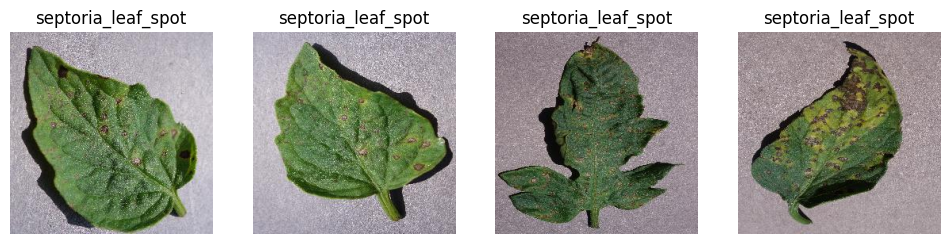

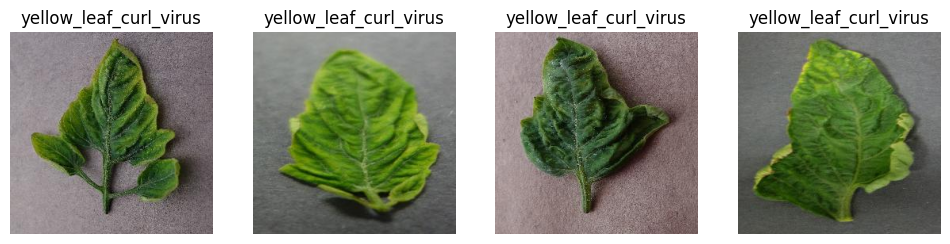

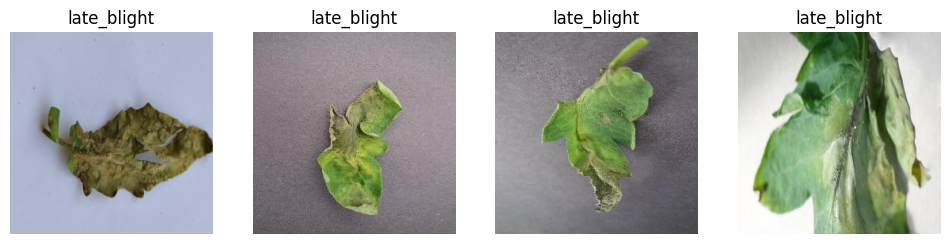

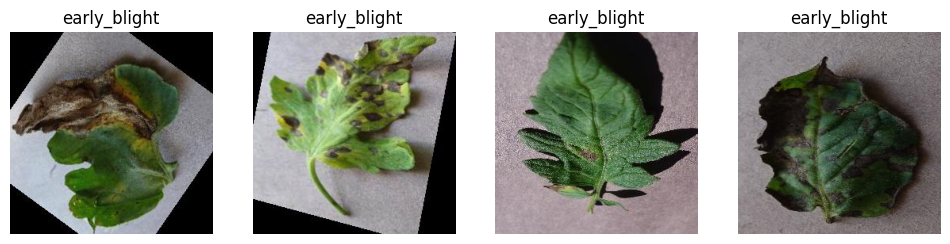

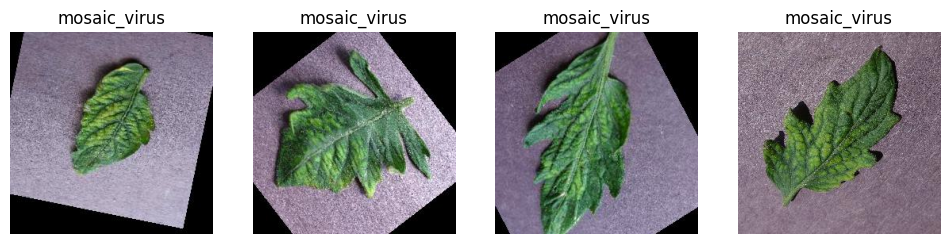

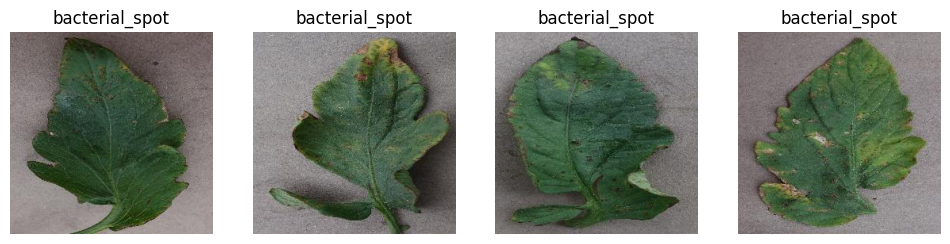

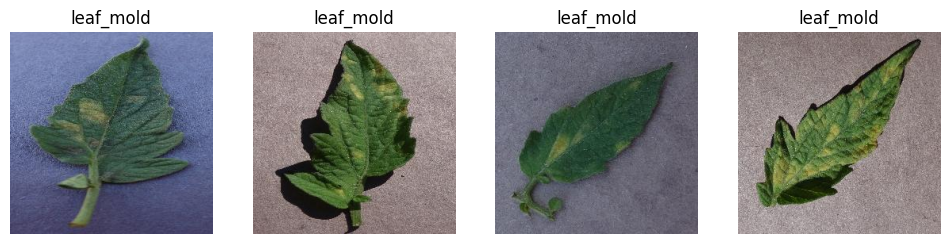

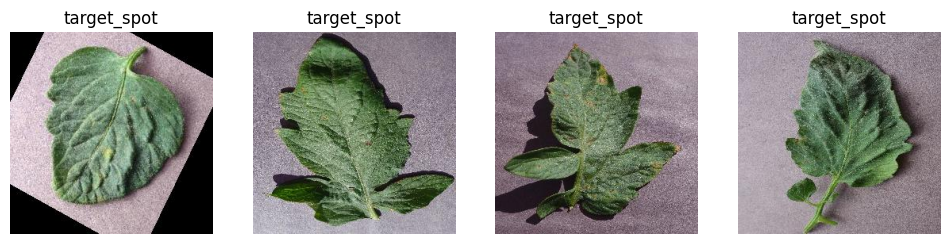

In [12]:
for label in labels:
    fig, axes = plt.subplots(1, 4, figsize=(12, 4))

    path_of_images = os.listdir(os.path.join(dataset_path, 'train', label))[:4]

    for i, image_name in enumerate(path_of_images):
        image_path = os.path.join(dataset_path, 'train', label, image_name)
        image = plt.imread(image_path)

        axes[i].imshow(image)
        axes[i].axis('off')
        axes[i].set_title(label)

    plt.show()

In [13]:
train_data,validation_data=tf.keras.preprocessing.image_dataset_from_directory(directory=dataset_path+'/train',
                                                               image_size=(255,255),batch_size=32,
                                                               label_mode='categorical',shuffle=True,
                                                              validation_split=0.2,subset='both',seed=1)

Found 17753 files belonging to 10 classes.
Using 14203 files for training.
Using 3550 files for validation.


In [14]:
train_data=train_data.map(lambda x,y:(x/255,y) )
validation_data=validation_data.map(lambda x,y:(x/255,y) )

In [15]:
test_data=tf.keras.preprocessing.image_dataset_from_directory(directory=dataset_path+'/test',
                                                              image_size=(255,255),batch_size=32,
                                                              label_mode='categorical')

Found 4440 files belonging to 10 classes.


In [16]:
test_data=test_data.map(lambda x,y:(x/255,y))

In [17]:
for image,target in train_data.take(1):
  print(target)

tf.Tensor(
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

_ _ _
# Train My Custom Models
_ _ _

# Model_1 (97% acc)

In [ ]:
from functools import partial
Conv2d=partial(tf.keras.layers.Conv2D,kernel_size=3,padding='same',strides=1 )

@tf.keras.utils.register_keras_serializable()
class Inception_mode(tf.keras.layers.Layer):
  def __init__ (self,filters,strides=1,activation='relu',**kwargs):
    super().__init__(**kwargs)
    self.filters=filters
    self.strides=strides
    self.activation=activation
    self.concat = tf.keras.layers.Concatenate(axis=-1)

    self.inception_layers_1=[tf.keras.layers.MaxPooling2D(pool_size=2,strides=strides,padding='same'),
                             Conv2d(filters=filters,activation=activation),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters)]

    self.inception_layers_2=[tf.keras.layers.AveragePooling2D(pool_size=2,strides=strides,padding='same'),
                             Conv2d(filters=filters),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters)]

    self.inception_layers_3=[Conv2d(filters=filters,strides=strides,activation=activation,kernel_size=1),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters,kernel_size=1)]



  def build(self, input_shape):
      input_shape = list(input_shape)
      input_shape[0] = 1
      input_shape = tuple(input_shape)

      dummy = tf.keras.backend.zeros(input_shape)
      _ = self.call(dummy)
      super().build(input_shape)


  def call(self, inputs):
      def apply_layers(x, layer_list):
          for layer in layer_list:
              x = layer(x)
          return x

      x1 = apply_layers(inputs, self.inception_layers_1)
      x2 = apply_layers(inputs, self.inception_layers_2)
      x3 = apply_layers(inputs, self.inception_layers_3)

      return self.concat([x1, x2, x3])

  def get_config(self):
    config = super().get_config()
    config.update({
        "filters": self.filters,
        "strides": self.strides,
        "activation": self.activation
    })
    return config

In [ ]:
inputs=tf.keras.layers.Input(shape=(255,255,3))
layer_2=tf.keras.layers.Conv2D(filters=32,kernel_size=2,padding='same',activation='relu')(inputs)
layer_3=Inception_mode(filters=32)(layer_2)
max_0=tf.keras.layers.MaxPool2D(pool_size=(2,2))(layer_3)
layer_4=tf.keras.layers.Conv2D(filters=64,kernel_size=2,padding='same',activation='relu')(max_0)
layer_5=Inception_mode(filters=64)(layer_4)
concatlayer_1=tf.keras.layers.Concatenate(axis=-1)([layer_4,layer_5])
max_1=tf.keras.layers.MaxPool2D(pool_size=(2,2))(concatlayer_1)
normal=tf.keras.layers.BatchNormalization()(max_1)
layer_6=tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu')(normal)
layer_7=Inception_mode(filters=128)(layer_6)
layer_8=tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu')(layer_7)
layer_9=Inception_mode(filters=256)(layer_8)
concatlayer_2=tf.keras.layers.Concatenate(axis=-1)([layer_6,layer_9])
max_2=tf.keras.layers.MaxPool2D(pool_size=(2,2))(concatlayer_2)
layer_10=tf.keras.layers.GlobalAveragePooling2D()(max_2)
outputs=tf.keras.layers.Dense(10,activation='softmax')(layer_10)

model_1=tf.keras.Model(inputs=inputs,outputs=outputs)








model_1.summary()
model_1.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9,nesterov=True),loss='categorical_crossentropy',metrics=['accuracy'])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 255, 255,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 255, 255,  │        416 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_mode      │ (None, 255, 255,  │     39,488 │ conv2d[0][0]      │
│ (Inception_mode)    │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 127, 127,  │          0 │ inception_mode[0… │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 127, 127,  │     24,640 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_mode_1    │ (None, 127, 127,  │    156,800 │ conv2d_7[0][0]    │
│ (Inception_mode)    │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 127, 127,  │          0 │ conv2d_7[0][0],   │
│ (Concatenate)       │ 256)              │            │ inception_mode_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 63, 63,    │          0 │ concatenate_2[0]… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 63, 63,    │      1,024 │ max_pooling2d_3[… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 63, 63,    │    295,040 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_mode_2    │ (None, 63, 63,    │    624,896 │ conv2d_14[0][0]   │
│ (Inception_mode)    │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 63, 63,    │    884,992 │ inception_mode_2… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_mode_3    │ (None, 63, 63,    │  2,494,976 │ conv2d_21[0][0]   │
│ (Inception_mode)    │ 768)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 63, 63,    │          0 │ conv2d_14[0][0],  │
│ (Concatenate)       │ 896)              │            │ inception_mode_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 31, 31,    │          0 │ concatenate_5[0]… │
│ (MaxPooling2D)      │ 896)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 896)       │          0 │ max_pooling2d_6[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │      8,970 │ global_average_p

 Total params: 4,531,242 (17.29 MB)

 Trainable params: 4,527,850 (17.27 MB)

 Non-trainable params: 3,392 (13.25 KB)

In [ ]:



def lr_schedule_exp(epoch):
  if epoch<7:
    return float(tf.exp(-epoch/10.)*0.01)/2
  elif epoch<15:
    return float(tf.exp(-epoch/10.)*0.01)/3
  else:
    return float(tf.exp(-epoch/10.)*0.01)/4

schedule_1=tf.keras.callbacks.LearningRateScheduler(lr_schedule_exp)
check_point_1=tf.keras.callbacks.ModelCheckpoint('model_1_best.keras',monitor='val_loss',verbose=1,save_best_only=True)
early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=5,verbose=1,restore_best_weights=True,mode='max')

In [ ]:
history_1=model_1.fit(train_data,epochs=20,validation_data=(validation_data),callbacks=[schedule_1,check_point_1,early_stop])

Epoch 1/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6773 - loss: 0.9575
Epoch 1: val_loss improved from inf to 3.55927, saving model to model_1_best.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 675s 1s/step - accuracy: 0.6775 - loss: 0.9568 - val_accuracy: 0.3992 - val_loss: 3.5593 - learning_rate: 0.0050
Epoch 2/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8629 - loss: 0.4160
Epoch 2: val_loss improved from 3.55927 to 1.45514, saving model to model_1_best.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 533s 1s/step - accuracy: 0.8629 - loss: 0.4159 - val_accuracy: 0.6313 - val_loss: 1.4551 - learning_rate: 0.0045
Epoch 3/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9039 - loss: 0.2784
Epoch 3: val_loss did not improve from 1.45514
444/444 ━━━━━━━━━━━━━━━━━━━━ 561s 1s/step - accuracy: 0.9039 - loss: 0.2783 - val_accuracy: 0.5344 - val_loss: 2.2563 - learning_rate: 0.0041
Epoch 4/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9278 - loss: 0.2115
Epoch 4: val_loss

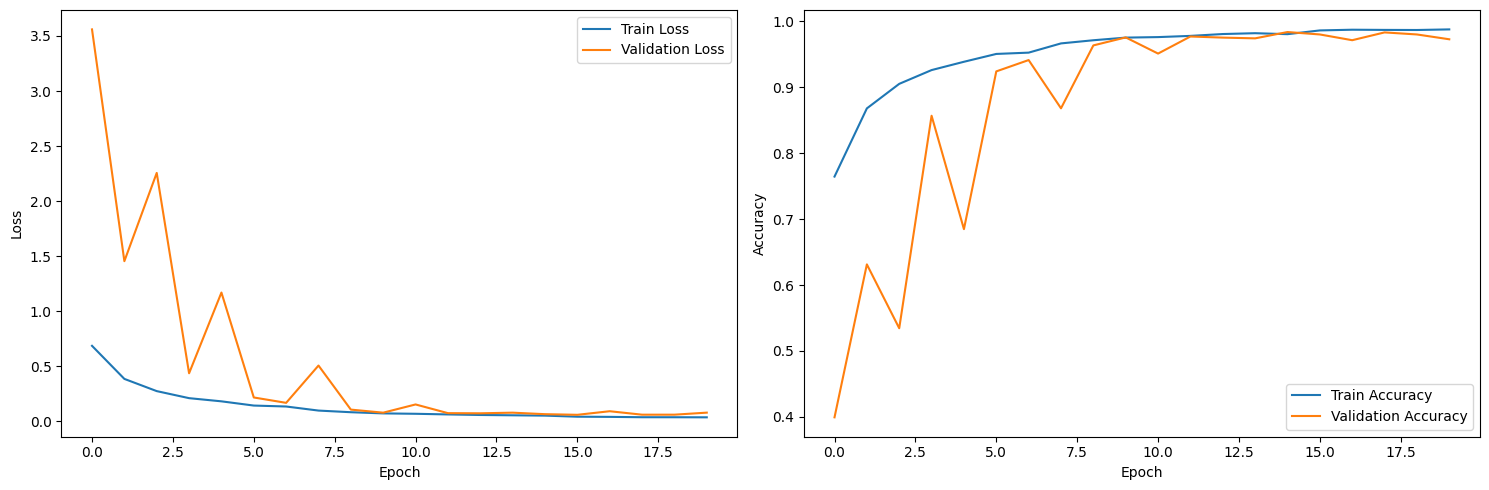

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].plot(history_1.history['loss'],label='Train Loss')
axes[0].plot(history_1.history['val_loss'],label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_1.history['accuracy'],label='Train Accuracy')
axes[1].plot(history_1.history['val_accuracy'],label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

In [ ]:
model_1=tf.keras.models.load_model('model_1_best.keras')

In [ ]:
model_1.evaluate(test_data)

139/139 ━━━━━━━━━━━━━━━━━━━━ 66s 453ms/step - accuracy: 0.9748 - loss: 0.0674


[0.0656537413597107, 0.9752252101898193]

# Model_2 (98.2% acc)

In [ ]:
@tf.keras.utils.register_keras_serializable()
class Recalibration_block(tf.keras.layers.Layer):
    def __init__(self, filters, activation='relu', **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.activation = activation


        self.gap = tf.keras.layers.GlobalAveragePooling2D()
        self.fc1 = tf.keras.layers.Dense(units=filters // 16, activation=activation)
        self.fc2 = tf.keras.layers.Dense(units=filters, activation='sigmoid')
        self.reshape = tf.keras.layers.Reshape((1, 1, filters))

    def build(self, input_shape):

        if input_shape[-1] != self.filters:
            raise ValueError(
                f"Recalibration_block expects {self.filters} filters, "
                f"but got input with {input_shape[-1]} channels."
            )
        super().build(input_shape)

    def call(self, inputs):
        x = self.gap(inputs)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.reshape(x)
        out = tf.multiply(inputs, x)
        return out

    def get_config(self):
        config = super().get_config()
        config.update({
            "filters": self.filters,
            "activation": self.activation
        })
        return config

In [ ]:

inputs=tf.keras.layers.Input(shape=(255,255,3))
max_1=tf.keras.layers.MaxPool2D(pool_size=(3,3))(inputs)
layer_2=tf.keras.layers.Conv2D(filters=32,kernel_size=2,padding='same',activation='relu')(max_1)
layer_3=Inception_mode(filters=32)(layer_2)
layer_4=tf.keras.layers.SeparableConv2D(filters=64,kernel_size=2,padding='same',activation='relu')(layer_3)
layer_5=Inception_mode(filters=64)(layer_4)
recal_0=Recalibration_block(filters=layer_5.shape[-1])(layer_5)
concatlayer_1=tf.keras.layers.Concatenate(axis=-1)([layer_4,recal_0,layer_5])
normal=tf.keras.layers.BatchNormalization()(concatlayer_1)
layer_6=tf.keras.layers.SeparableConv2D(filters=128,kernel_size=3,padding='same',activation='relu')(normal)
layer_7=Inception_mode(filters=128)(layer_6)
layer_8=tf.keras.layers.SeparableConv2D(filters=256,kernel_size=3,padding='same',activation='relu')(layer_7)
layer_9=Inception_mode(filters=256)(layer_8)
recal_1=Recalibration_block(filters=layer_9.shape[-1])(layer_9)
concatlayer_2=tf.keras.layers.Concatenate(axis=-1)([layer_8,recal_1,layer_9])
layer_10=tf.keras.layers.GlobalAveragePooling2D()(recal_1)
outputs=tf.keras.layers.Dense(10,activation='softmax')(layer_10)

model_2=tf.keras.Model(inputs=inputs,outputs=outputs)
model_2.summary()
model_2.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9,nesterov=True),loss='categorical_crossentropy',metrics=['accuracy'])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 255, 255,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 85, 85, 3) │          0 │ input_layer_1[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 85, 85,    │        416 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_mode      │ (None, 85, 85,    │     39,488 │ conv2d_1[0][0]    │
│ (Inception_mode)    │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 85, 85,    │      6,592 │ inception_mode[0… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_mode_1    │ (None, 85, 85,    │    156,800 │ separable_conv2d… │
│ (Inception_mode)    │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recalibration_block │ (None, 85, 85,    │      4,812 │ inception_mode_1… │
│ (Recalibration_blo… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 85, 85,    │          0 │ separable_conv2d… │
│ (Concatenate)       │ 448)              │            │ recalibration_bl… │
│                     │                   │            │ inception_mode_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 85, 85,    │      1,792 │ concatenate_2[0]… │
│ (BatchNormalizatio… │ 448)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 85, 85,    │     61,504 │ batch_normalizat… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_mode_2    │ (None, 85, 85,    │    624,896 │ separable_conv2d… │
│ (Inception_mode)    │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 85, 85,    │    102,016 │ inception_mode_2… │
│ (SeparableConv2D)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_mode_3    │ (None, 85, 85,    │  2,494,976 │ separable_conv2d… │
│ (Inception_mode)    │ 768)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recalibration_bloc… │ (None, 85, 85,    │     74,544 │ inception_mode_3… │
│ (Recalibration_blo… │ 768)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 768)       │          0 │ recalibration_bl… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 10)        │      7,690 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,575,526 (13.64 MB)

 Trainable params: 3,571,750 (13.63 MB)

 Non-trainable params: 3,776 (14.75 KB)

In [ ]:
def lr_schedule_exp(epoch):
  if epoch<7:
    return float(tf.exp(-epoch/10.)*0.01)/2
  elif epoch<17:
    return float(tf.exp(-epoch/10.)*0.01)/3
  else:
    return float(tf.exp(-epoch/10.)*0.01)/4

schedule_2=tf.keras.callbacks.LearningRateScheduler(lr_schedule_exp)
check_point_2=tf.keras.callbacks.ModelCheckpoint('model_2_best.keras',monitor='val_accuracy',verbose=1,save_best_only=True)
early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=5,verbose=1,restore_best_weights=True,mode='max')

In [ ]:
history_2=model_2.fit(train_data,epochs=20,validation_data=(validation_data),callbacks=[schedule_2,check_point_2,early_stop])

Epoch 1/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6238 - loss: 1.1148
Epoch 1: val_accuracy improved from -inf to 0.35606, saving model to model_2_best.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 625s 1s/step - accuracy: 0.6240 - loss: 1.1141 - val_accuracy: 0.3561 - val_loss: 1.9506 - learning_rate: 0.0050
Epoch 2/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8457 - loss: 0.4561
Epoch 2: val_accuracy improved from 0.35606 to 0.38394, saving model to model_2_best.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 496s 1s/step - accuracy: 0.8457 - loss: 0.4560 - val_accuracy: 0.3839 - val_loss: 4.4799 - learning_rate: 0.0045
Epoch 3/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8903 - loss: 0.3287
Epoch 3: val_accuracy improved from 0.38394 to 0.42901, saving model to model_2_best.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 496s 1s/step - accuracy: 0.8903 - loss: 0.3286 - val_accuracy: 0.4290 - val_loss: 3.2259 - learning_rate: 0.0041
Epoch 4/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/ste

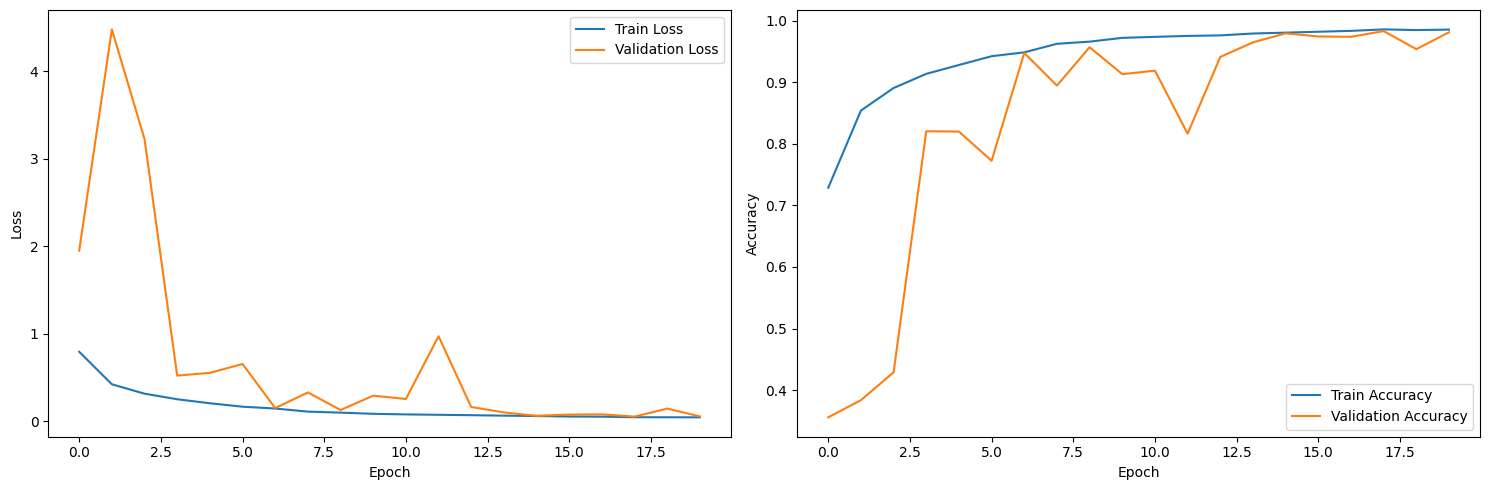

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].plot(history_2.history['loss'],label='Train Loss')
axes[0].plot(history_2.history['val_loss'],label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_2.history['accuracy'],label='Train Accuracy')
axes[1].plot(history_2.history['val_accuracy'],label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

In [ ]:
model_2=tf.keras.models.load_model('model_2_best.keras')

In [ ]:
model_2.evaluate(test_data)

139/139 ━━━━━━━━━━━━━━━━━━━━ 65s 444ms/step - accuracy: 0.9828 - loss: 0.0525


[0.05186491832137108, 0.9826576709747314]

# Model_3 (98.6% acc)

In [ ]:

@tf.keras.utils.register_keras_serializable()
class Recalibration_block(tf.keras.layers.Layer):
  def __init__(self,filters,activation='relu',**kwargs):
    super().__init__(**kwargs)
    self.filters=filters
    self.activation=activation

    self.block=[tf.keras.layers.GlobalAveragePooling2D(),
                tf.keras.layers.Dense(units=filters//16,activation=activation),
                tf.keras.layers.Dense(units=filters,activation='sigmoid'),
                tf.keras.layers.Reshape((1,1,filters))]

  def call(self,inputs):
    x=inputs
    for layer in self.block:
      x=layer(x)
    out=tf.multiply(inputs,x)
    return out

  def get_config(self):
    config = super().get_config()
    config.update({
        "filters": self.filters,
        "activation": self.activation
    })
    return config




from functools import partial
Conv2d=partial(tf.keras.layers.Conv2D,kernel_size=3,padding='same',strides=1 )

@tf.keras.utils.register_keras_serializable()
class Inception_mode(tf.keras.layers.Layer):
  def __init__ (self,filters,strides=1,activation='relu',**kwargs):
    super().__init__(**kwargs)
    self.filters=filters
    self.strides=strides
    self.activation=activation
    self.concat = tf.keras.layers.Concatenate(axis=-1)

    self.inception_layers_1=[tf.keras.layers.MaxPooling2D(pool_size=2,strides=strides,padding='same'),
                             Conv2d(filters=filters,activation=activation),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters)]

    self.inception_layers_2=[tf.keras.layers.AveragePooling2D(pool_size=2,strides=strides,padding='same'),
                             Conv2d(filters=filters),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters)]

    self.inception_layers_3=[Conv2d(filters=filters,strides=strides,activation=activation,kernel_size=1),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters,kernel_size=1)]


    self.inception_layers_4=[Conv2d(filters=filters),
                             Recalibration_block(filters=filters),
                             ]

  def build(self, input_shape):
      input_shape = list(input_shape)
      input_shape[0] = 1
      input_shape = tuple(input_shape)

      dummy = tf.keras.backend.zeros(input_shape)
      _ = self.call(dummy)
      super().build(input_shape)


  def call(self, inputs):
      def apply_layers(x, layer_list):
          for layer in layer_list:
              x = layer(x)
          return x

      x1 = apply_layers(inputs, self.inception_layers_1)
      x2 = apply_layers(inputs, self.inception_layers_2)
      x3 = apply_layers(inputs, self.inception_layers_3)
      x4 = apply_layers(inputs, self.inception_layers_4)
      return self.concat([x1, x2, x3, x4])

  def get_config(self):
    config = super().get_config()
    config.update({
        "filters": self.filters,
        "strides": self.strides,
        "activation": self.activation
    })
    return config

In [ ]:
inputs=tf.keras.layers.Input(shape=(255,255,3))
max_1=tf.keras.layers.MaxPool2D(pool_size=(3,3))(inputs)
layer_1=Inception_mode(filters=32)(max_1)
layer_2=Inception_mode(filters=64)(layer_1)
concatlayer_1=tf.keras.layers.Concatenate(axis=-1)([layer_1,layer_2])
layer_3=Inception_mode(filters=128)(concatlayer_1)
layer_4=Inception_mode(filters=256)(layer_3)
concatlayer_2=tf.keras.layers.Concatenate(axis=-1)([layer_3,layer_4])
layer_5=tf.keras.layers.GlobalAveragePooling2D()(concatlayer_2)
outputs=tf.keras.layers.Dense(10,activation='softmax')(layer_5)

model_3=tf.keras.Model(inputs=inputs,outputs=outputs)








model_3.summary()
model_3.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9,nesterov=True),loss='categorical_crossentropy',metrics=['accuracy'])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 255, 255,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 85, 85, 3) │          0 │ input_layer_1[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_mode_1    │ (None, 85, 85,    │     22,914 │ max_pooling2d_2[… │
│ (Inception_mode)    │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_mode_2    │ (None, 85, 85,    │    308,996 │ inception_mode_1… │
│ (Inception_mode)    │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 85, 85,    │          0 │ inception_mode_1… │
│ (Concatenate)       │ 384)              │            │ inception_mode_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_mode_3    │ (None, 85, 85,    │  1,692,168 │ concatenate_3[0]… │
│ (Inception_mode)    │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_mode_4    │ (None, 85, 85,    │  4,928,528 │ inception_mode_3… │
│ (Inception_mode)    │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 85, 85,    │          0 │ inception_mode_3… │
│ (Concatenate)       │ 1536)             │            │ inception_mode_4… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1536)      │          0 │ concatenate_6[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 10)        │     15,370 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,967,976 (26.58 MB)

 Trainable params: 6,965,096 (26.57 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [ ]:

def lr_schedule_exp(epoch):
  if epoch<7:
    return float(tf.exp(-epoch/10.)*0.01)
  elif epoch<15:
    return float(tf.exp(-epoch/10.)*0.01)/2
  else:
    return float(tf.exp(-epoch/10.)*0.01)/3

schedule_3=tf.keras.callbacks.LearningRateScheduler(lr_schedule_exp)
check_point_3=tf.keras.callbacks.ModelCheckpoint('model_3_best.keras',monitor='val_accuracy',verbose=1,save_best_only=True,mode='max')
early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=5,verbose=1,restore_best_weights=True,mode='max')

In [ ]:
history_3=model_3.fit(train_data,epochs=20,validation_data=(validation_data),callbacks=[schedule_3,check_point_3,early_stop])

Epoch 1/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6288 - loss: 1.1323
Epoch 1: val_accuracy improved from -inf to 0.42113, saving model to model_3_best.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 890s 2s/step - accuracy: 0.6290 - loss: 1.1316 - val_accuracy: 0.4211 - val_loss: 2.2308 - learning_rate: 0.0100
Epoch 2/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8200 - loss: 0.5222
Epoch 2: val_accuracy improved from 0.42113 to 0.81352, saving model to model_3_best.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 712s 2s/step - accuracy: 0.8201 - loss: 0.5221 - val_accuracy: 0.8135 - val_loss: 0.5898 - learning_rate: 0.0090
Epoch 3/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8748 - loss: 0.3650
Epoch 3: val_accuracy did not improve from 0.81352
444/444 ━━━━━━━━━━━━━━━━━━━━ 742s 2s/step - accuracy: 0.8748 - loss: 0.3650 - val_accuracy: 0.6363 - val_loss: 1.4532 - learning_rate: 0.0082
Epoch 4/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9031 - loss: 0.2702
Epoc

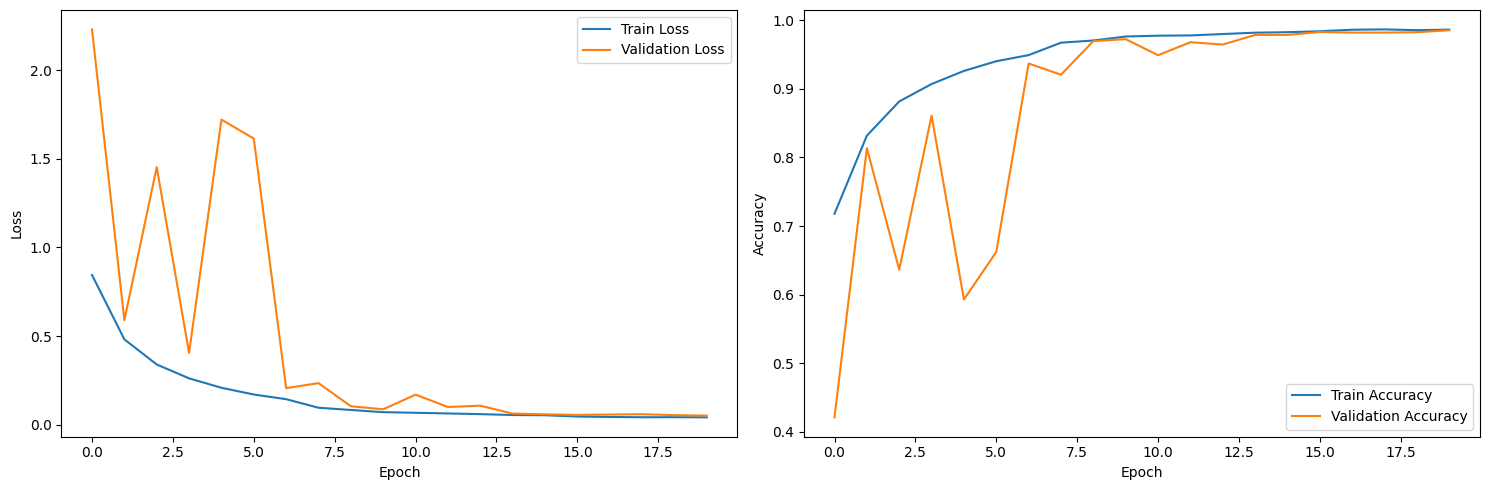

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].plot(history_3.history['loss'],label='Train Loss')
axes[0].plot(history_3.history['val_loss'],label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_3.history['accuracy'],label='Train Accuracy')
axes[1].plot(history_3.history['val_accuracy'],label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

In [ ]:
model_3=tf.keras.models.load_model('model_3_best.keras')


In [ ]:
model_3.evaluate(test_data)

139/139 ━━━━━━━━━━━━━━━━━━━━ 95s 663ms/step - accuracy: 0.9859 - loss: 0.0412


[0.05121026188135147, 0.9826576709747314]

In [ ]:
import numpy as np
from sklearn.metrics import classification_report,confusion_matrix

def predict_and_evaluate(model, test_data):
    y_true = []
    y_pred = []

    for images, labels in test_data:

        predictions = model.predict(images, verbose=0)


        true_labels = np.argmax(labels.numpy(), axis=1)
        pred_labels = np.argmax(predictions, axis=1)


        y_true.extend(true_labels)
        y_pred.extend(pred_labels)


    print("Classification Report:\n")
    print(classification_report(y_true, y_pred))

    return np.array(y_true), np.array(y_pred)

In [ ]:
y_true, y_pred = predict_and_evaluate(model_3, test_data)

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       444
           1       0.97      0.95      0.96       444
           2       0.98      1.00      0.99       444
           3       0.97      0.97      0.97       444
           4       1.00      0.99      1.00       444
           5       1.00      0.99      0.99       444
           6       1.00      1.00      1.00       444
           7       1.00      0.99      0.99       444
           8       0.98      1.00      0.99       444
           9       0.99      1.00      0.99       444

    accuracy                           0.99      4440
   macro avg       0.99      0.99      0.99      4440
weighted avg       0.99      0.99      0.99      4440



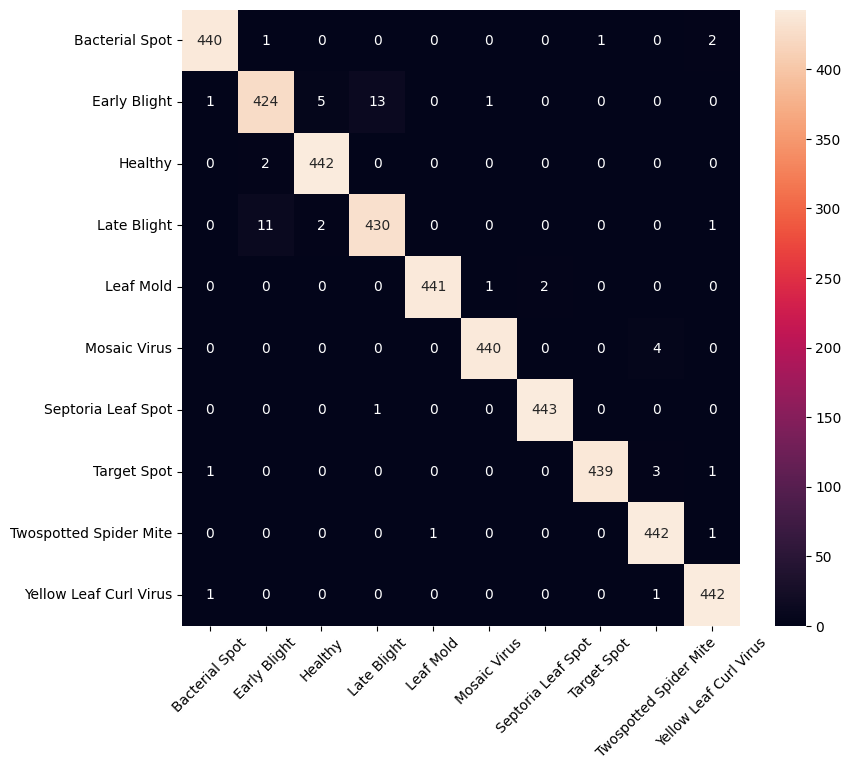

In [ ]:
class_names = ['Bacterial Spot',
'Early Blight',
'Healthy',
'Late Blight',
'Leaf Mold',
'Mosaic Virus',
'Septoria Leaf Spot',
'Target Spot',
'Twospotted Spider Mite',
'Yellow Leaf Curl Virus']
plt.figure(figsize=(9,8))
sns.heatmap(confusion_matrix(y_true,y_pred),annot=True,fmt='d',xticklabels=class_names, yticklabels=class_names)
plt.xticks(rotation=45)
plt.show()

# Model_4 (98.72% acc) Best Model

In [ ]:

@tf.keras.utils.register_keras_serializable()
class Recalibration_block(tf.keras.layers.Layer):
    def __init__(self, filters, activation='relu', **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.activation = activation


        self.gap = tf.keras.layers.GlobalAveragePooling2D()
        self.dense1 = tf.keras.layers.Dense(units=filters // 16, activation=activation)
        self.dense2 = tf.keras.layers.Dense(units=filters, activation='sigmoid')
        self.reshape = tf.keras.layers.Reshape((1, 1, filters))

    def build(self, input_shape):

        self.gap.build(input_shape)
        gap_shape = self.gap.compute_output_shape(input_shape)

        self.dense1.build(gap_shape)
        dense1_shape = self.dense1.compute_output_shape(gap_shape)

        self.dense2.build(dense1_shape)
        dense2_shape = self.dense2.compute_output_shape(dense1_shape)

        self.reshape.build(dense2_shape)


        super().build(input_shape)

    def call(self, inputs):
        x = self.gap(inputs)
        x = self.dense1(x)
        x = self.dense2(x)
        x = self.reshape(x)
        return tf.multiply(inputs, x)

    def get_config(self):
        config = super().get_config()
        config.update({
            "filters": self.filters,
            "activation": self.activation,
        })
        return config

from functools import partial
Conv2d=partial(tf.keras.layers.Conv2D,kernel_size=3,padding='same',strides=1 )
@tf.keras.utils.register_keras_serializable()
class Inception_mode(tf.keras.layers.Layer):
  def __init__ (self,filters,strides=1,activation='relu',**kwargs):
    super().__init__(**kwargs)
    self.filters=filters
    self.strides=strides
    self.activation=activation
    self.concat = tf.keras.layers.Concatenate(axis=-1)

    self.inception_layers_1=[tf.keras.layers.MaxPooling2D(pool_size=2,strides=strides,padding='same'),
                             Conv2d(filters=filters,activation=activation),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters)]

    self.inception_layers_2=[tf.keras.layers.AveragePooling2D(pool_size=2,strides=strides,padding='same'),
                             Conv2d(filters=filters),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters)]

    self.inception_layers_3=[Conv2d(filters=filters,strides=strides,activation=activation,kernel_size=1),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters,kernel_size=1)]




  def build(self, input_shape):
      input_shape = list(input_shape)
      input_shape[0] = 1
      input_shape = tuple(input_shape)

      dummy = tf.keras.backend.zeros(input_shape)
      _ = self.call(dummy)
      super().build(input_shape)


  def call(self, inputs):
      def apply_layers(x, layer_list):
          for layer in layer_list:
              x = layer(x)
          return x

      x1 = apply_layers(inputs, self.inception_layers_1)
      x2 = apply_layers(inputs, self.inception_layers_2)
      x3 = apply_layers(inputs, self.inception_layers_3)

      return self.concat([x1, x2, x3])

  def get_config(self):
    config = super().get_config()
    config.update({
        "filters": self.filters,
        "strides": self.strides,
        "activation": self.activation
    })
    return config

In [ ]:
inputs=tf.keras.layers.Input(shape=(255,255,3))
max=tf.keras.layers.MaxPool2D(pool_size=(2,2))(inputs)
in_block_1=Inception_mode(filters=68)(max)
recal_1=Recalibration_block(filters=in_block_1.shape[-1])(in_block_1)
conv_1=tf.keras.layers.Conv2D(filters=204,kernel_size=3,padding='valid',activation='relu',strides=2)(recal_1)
recal_2=Recalibration_block(filters=conv_1.shape[-1])(conv_1)
in_block_2=Inception_mode(filters=128)(recal_2)
conv_2=tf.keras.layers.Conv2D(filters=384,kernel_size=2,padding='same',activation='relu',strides=1)(in_block_2)
recal_3=Recalibration_block(filters=conv_2.shape[-1])(conv_2)
layer_5=tf.keras.layers.GlobalMaxPooling2D()(recal_3)
outputs=tf.keras.layers.Dense(10,activation='softmax')(layer_5)

model_4=tf.keras.Model(inputs=inputs,outputs=outputs)








model_4.summary()
model_4.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9,nesterov=True),loss='categorical_crossentropy',metrics=['accuracy'])

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 255, 255, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_mode_2                │ (None, 127, 127, 204)  │        92,956 │
│ (Inception_mode)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ recalibration_block_3           │ (None, 127, 127, 204)  │         5,112 │
│ (Recalibration_block)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 63, 63, 204)    │       374,748 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ recalibration_block_4           │ (None, 63, 63, 204)    │         5,112 │
│ (Recalibration_block)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_mode_3                │ (None, 63, 63, 384)    │       809,728 │
│ (Inception_mode)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 63, 63, 384)    │       590,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ recalibration_block_5           │ (None, 63, 63, 384)    │        18,840 │
│ (Recalibration_block)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_1          │ (None, 384)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         3,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,900,554 (7.25 MB)

 Trainable params: 1,899,378 (7.25 MB)

 Non-trainable params: 1,176 (4.59 KB)

In [ ]:
def lr_schedule_exp(epoch):
  if epoch<4:
    return float(tf.exp(-epoch/10.)*0.01)/2
  elif epoch<8:
    return float(tf.exp(-epoch/10.)*0.01)/3
  else:
    return float(tf.exp(-epoch/10.)*0.01)/4

schedule_4=tf.keras.callbacks.LearningRateScheduler(lr_schedule_exp)
check_point_4=tf.keras.callbacks.ModelCheckpoint('model_4_best.keras',monitor='val_accuracy',verbose=1,save_best_only=True,mode='max')
early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=3,verbose=1,restore_best_weights=True,mode='max')

In [ ]:
history_4=model_4.fit(train_data,epochs=15,validation_data=(validation_data),callbacks=[schedule_4,check_point_4,early_stop])

Epoch 1/15
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.6207 - loss: 1.1797
Epoch 1: val_accuracy improved from -inf to 0.52197, saving model to model_4_best.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 325s 704ms/step - accuracy: 0.6210 - loss: 1.1786 - val_accuracy: 0.5220 - val_loss: 2.0438 - learning_rate: 0.0050
Epoch 2/15
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.9040 - loss: 0.2872
Epoch 2: val_accuracy improved from 0.52197 to 0.90535, saving model to model_4_best.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 266s 599ms/step - accuracy: 0.9041 - loss: 0.2872 - val_accuracy: 0.9054 - val_loss: 0.2715 - learning_rate: 0.0045
Epoch 3/15
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.9393 - loss: 0.1764
Epoch 3: val_accuracy did not improve from 0.90535
444/444 ━━━━━━━━━━━━━━━━━━━━ 323s 601ms/step - accuracy: 0.9393 - loss: 0.1764 - val_accuracy: 0.8969 - val_loss: 0.3289 - learning_rate: 0.0041
Epoch 4/15
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.957

In [ ]:
model_4=tf.keras.models.load_model('/content/model_4_best (986).keras')
model_4.evaluate(test_data)

139/139 ━━━━━━━━━━━━━━━━━━━━ 45s 210ms/step - accuracy: 0.9882 - loss: 0.0478


[0.04611709341406822, 0.9860360622406006]

In [ ]:
history_4=model_4.fit(train_data,epochs=20,validation_data=(validation_data),callbacks=[schedule_4,check_point_4,early_stop],initial_epoch=15)

Epoch 16/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.9990 - loss: 0.0070
Epoch 16: val_accuracy improved from -inf to 0.98620, saving model to model_4_best.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 313s 648ms/step - accuracy: 0.9990 - loss: 0.0070 - val_accuracy: 0.9862 - val_loss: 0.0481 - learning_rate: 5.5783e-04
Epoch 17/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.9988 - loss: 0.0075
Epoch 17: val_accuracy improved from 0.98620 to 0.98704, saving model to model_4_best.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 251s 566ms/step - accuracy: 0.9988 - loss: 0.0075 - val_accuracy: 0.9870 - val_loss: 0.0476 - learning_rate: 5.0474e-04
Epoch 18/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.9994 - loss: 0.0062
Epoch 18: val_accuracy did not improve from 0.98704
444/444 ━━━━━━━━━━━━━━━━━━━━ 251s 565ms/step - accuracy: 0.9994 - loss: 0.0062 - val_accuracy: 0.9865 - val_loss: 0.0481 - learning_rate: 4.5671e-04
Epoch 19/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/ste

In [ ]:
model_4.evaluate(test_data)

139/139 ━━━━━━━━━━━━━━━━━━━━ 22s 155ms/step - accuracy: 0.9872 - loss: 0.0468


[0.04796798899769783, 0.9849098920822144]

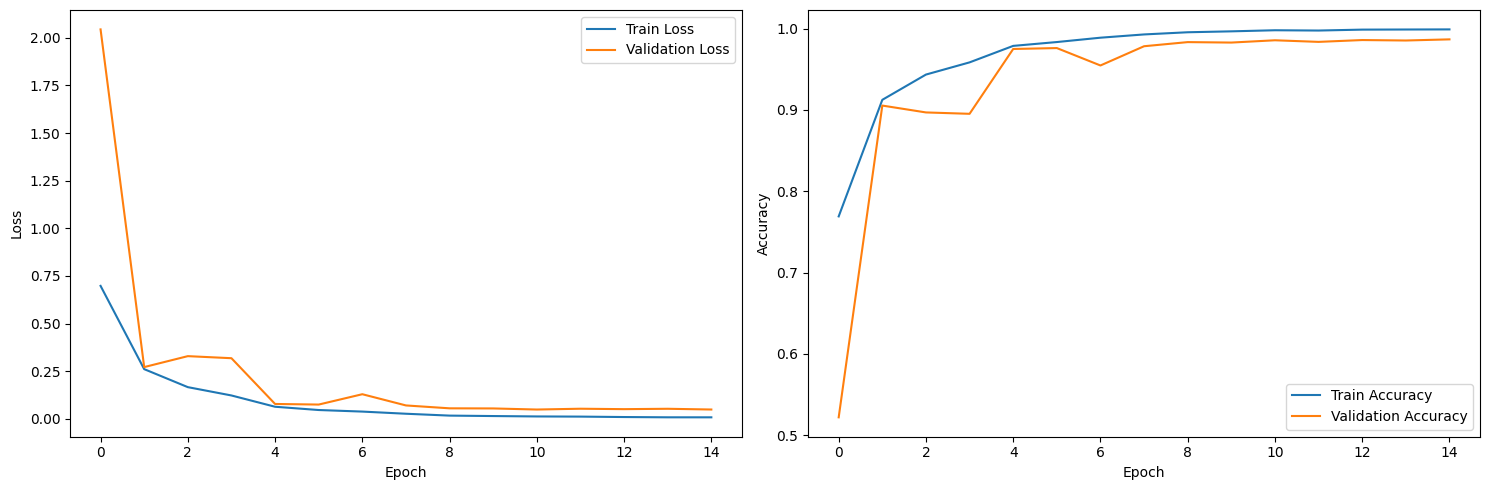

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].plot(history_4.history['loss'],label='Train Loss')
axes[0].plot(history_4.history['val_loss'],label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_4.history['accuracy'],label='Train Accuracy')
axes[1].plot(history_4.history['val_accuracy'],label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

In [ ]:
import numpy as np
from sklearn.metrics import classification_report,confusion_matrix

def predict_and_evaluate(model, test_data):
    y_true = []
    y_pred = []

    for images, labels in test_data:

        predictions = model.predict(images, verbose=0)


        true_labels = np.argmax(labels.numpy(), axis=1)
        pred_labels = np.argmax(predictions, axis=1)


        y_true.extend(true_labels)
        y_pred.extend(pred_labels)


    print("Classification Report:\n")
    print(classification_report(y_true, y_pred))

    return np.array(y_true), np.array(y_pred)

In [ ]:
y_true, y_pred = predict_and_evaluate(model_4, test_data)

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       444
           1       0.97      0.95      0.96       444
           2       0.99      0.99      0.99       444
           3       0.95      0.98      0.96       444
           4       1.00      1.00      1.00       444
           5       0.99      1.00      0.99       444
           6       1.00      0.99      0.99       444
           7       0.98      0.98      0.98       444
           8       0.99      0.98      0.98       444
           9       0.98      0.99      0.99       444

    accuracy                           0.98      4440
   macro avg       0.98      0.98      0.98      4440
weighted avg       0.98      0.98      0.98      4440



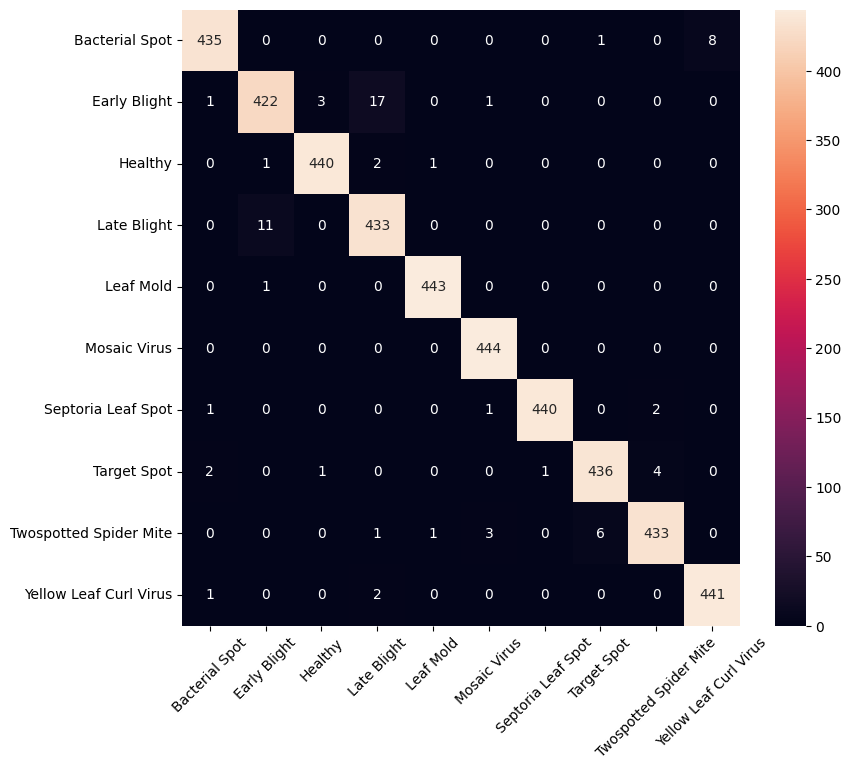

In [ ]:
class_names = ['Bacterial Spot',
'Early Blight',
'Healthy',
'Late Blight',
'Leaf Mold',
'Mosaic Virus',
'Septoria Leaf Spot',
'Target Spot',
'Twospotted Spider Mite',
'Yellow Leaf Curl Virus']
plt.figure(figsize=(9,8))
sns.heatmap(confusion_matrix(y_true,y_pred),annot=True,fmt='d',xticklabels=class_names, yticklabels=class_names)
plt.xticks(rotation=45)
plt.show()

_ _ _
# Transfer Learning Models
_ _ _

# ResNet50

In [ ]:


base_model = tf.keras.applications.ResNet50(weights="imagenet", include_top=False, input_shape=(255, 255, 3))
for layer in base_model.layers[:int(len(base_model.layers)*0.2)]:
  layer.trainable=False
inputs=tf.keras.layers.Input(shape=(255,255,3))

x = base_model(inputs)



x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
output = tf.keras.layers.Dense(10, activation="softmax")(x)
Res_model = tf.keras.Model(inputs=inputs, outputs=output)
Res_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 255, 255, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 23,588,490 (89.98 MB)

 Non-trainable params: 262,784 (1.00 MB)

In [ ]:

def lr_schedule_exp(epoch):
    return float(tf.exp(-epoch/10.)*0.01)/2
schedule_res=tf.keras.callbacks.LearningRateScheduler(lr_schedule_exp)
check_point_res=tf.keras.callbacks.ModelCheckpoint('model_res.keras',monitor='val_accuracy',verbose=1,save_best_only=True)
early_stop_res=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=5,verbose=1,restore_best_weights=True,mode='max')

In [ ]:
Res_model.compile(loss='categorical_crossentropy',optimizer=tf.keras.optimizers.SGD(momentum=0.9,
                                                                                    nesterov=True),metrics=['accuracy'])

In [ ]:
res_history=Res_model.fit(train_data,epochs=20,validation_data=validation_data,callbacks=[schedule_res,check_point_res,early_stop_res])

Epoch 1/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.5895 - loss: 1.1857
Epoch 1: val_accuracy improved from -inf to 0.27972, saving model to model_res.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 175s 329ms/step - accuracy: 0.5897 - loss: 1.1850 - val_accuracy: 0.2797 - val_loss: 3.7916 - learning_rate: 0.0050
Epoch 2/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.8402 - loss: 0.4593
Epoch 2: val_accuracy improved from 0.27972 to 0.59465, saving model to model_res.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 129s 291ms/step - accuracy: 0.8402 - loss: 0.4592 - val_accuracy: 0.5946 - val_loss: 1.1687 - learning_rate: 0.0045
Epoch 3/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9051 - loss: 0.2687
Epoch 3: val_accuracy did not improve from 0.59465
444/444 ━━━━━━━━━━━━━━━━━━━━ 138s 310ms/step - accuracy: 0.9052 - loss: 0.2687 - val_accuracy: 0.4268 - val_loss: 2.0814 - learning_rate: 0.0041
Epoch 4/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.9495 - lo

In [ ]:
Res_model=tf.keras.models.load_model('/content/model_res.keras')
Res_model.evaluate(test_data)

139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 126ms/step - accuracy: 0.9538 - loss: 0.1974


[0.19559268653392792, 0.953153133392334]

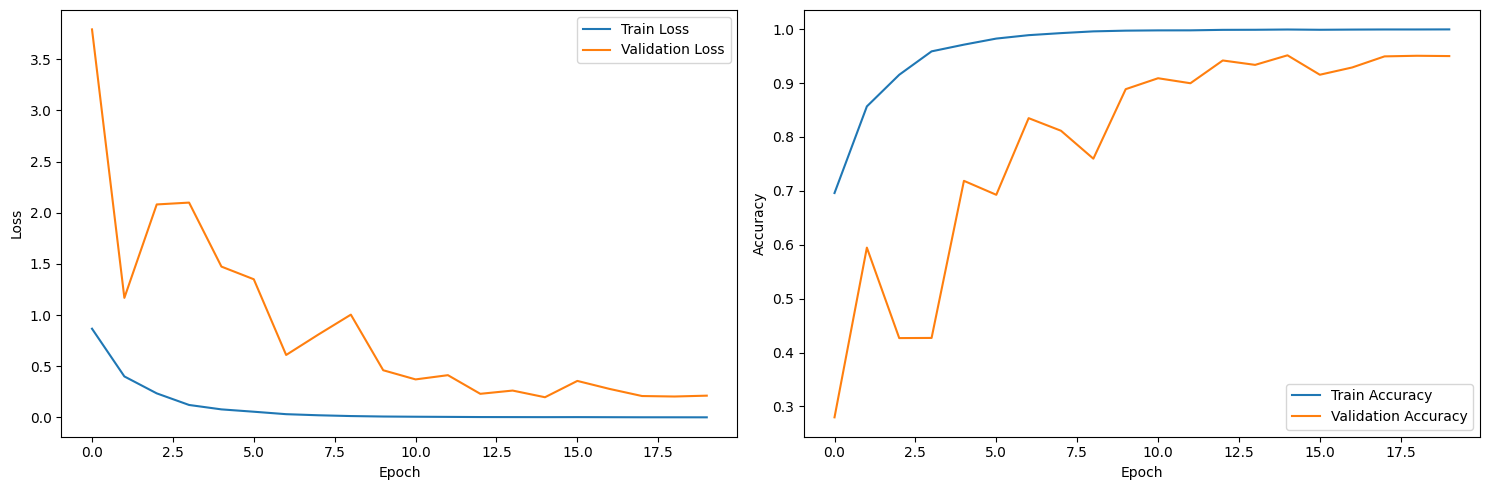

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].plot(res_history.history['loss'],label='Train Loss')
axes[0].plot(res_history.history['val_loss'],label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(res_history.history['accuracy'],label='Train Accuracy')
axes[1].plot(res_history.history['val_accuracy'],label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

# Inception V3 (99.2% acc)

In [ ]:
base_model_2=tf.keras.applications.InceptionV3(weights='imagenet',include_top=False, input_shape=(255, 255, 3))
for layer in base_model_2.layers[:int(len(base_model_2.layers)*0.2)]:
  layer.trainable=False

inputs=tf.keras.layers.Input(shape=(255,255,3))

x = base_model_2(inputs)



x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(500, activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
output = tf.keras.layers.Dense(10, activation="softmax")(x)
Ins_model = tf.keras.Model(inputs=inputs, outputs=output)
Ins_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 255, 255, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 6, 6, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 500)            │     1,024,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,832,294 (87.10 MB)

 Trainable params: 22,093,174 (84.28 MB)

 Non-trainable params: 739,120 (2.82 MB)

In [ ]:
def lr_schedule_exp(epoch):
  if epoch<4:
    return float(tf.exp(-epoch/10.)*0.01)
  elif epoch<8:
    return float(tf.exp(-epoch/10.)*0.01)/2
  else:
    return float(tf.exp(-epoch/10.)*0.01)/4
schedule_In=tf.keras.callbacks.LearningRateScheduler(lr_schedule_exp)
check_point_In=tf.keras.callbacks.ModelCheckpoint('model_res.keras',monitor='val_accuracy',verbose=1,save_best_only=True)
early_stop_In=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=3,verbose=1,restore_best_weights=True,mode='max')

In [ ]:
Ins_model.compile(loss='categorical_crossentropy',optimizer=tf.keras.optimizers.SGD(momentum=0.9,
                                                                                    nesterov=True),metrics=['accuracy'])

In [ ]:
in_history=Ins_model.fit(train_data,epochs=10,validation_data=validation_data,callbacks=[schedule_In,check_point_In,early_stop_In])

Epoch 1/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.7911 - loss: 0.6397
Epoch 1: val_accuracy improved from -inf to 0.92310, saving model to model_res.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 179s 304ms/step - accuracy: 0.7913 - loss: 0.6390 - val_accuracy: 0.9231 - val_loss: 0.2346 - learning_rate: 0.0100
Epoch 2/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9706 - loss: 0.0902
Epoch 2: val_accuracy improved from 0.92310 to 0.93437, saving model to model_res.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 103s 231ms/step - accuracy: 0.9706 - loss: 0.0902 - val_accuracy: 0.9344 - val_loss: 0.2109 - learning_rate: 0.0090
Epoch 3/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9884 - loss: 0.0353
Epoch 3: val_accuracy improved from 0.93437 to 0.97887, saving model to model_res.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 102s 229ms/step - accuracy: 0.9884 - loss: 0.0353 - val_accuracy: 0.9789 - val_loss: 0.0651 - learning_rate: 0.0082
Epoch 4/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 

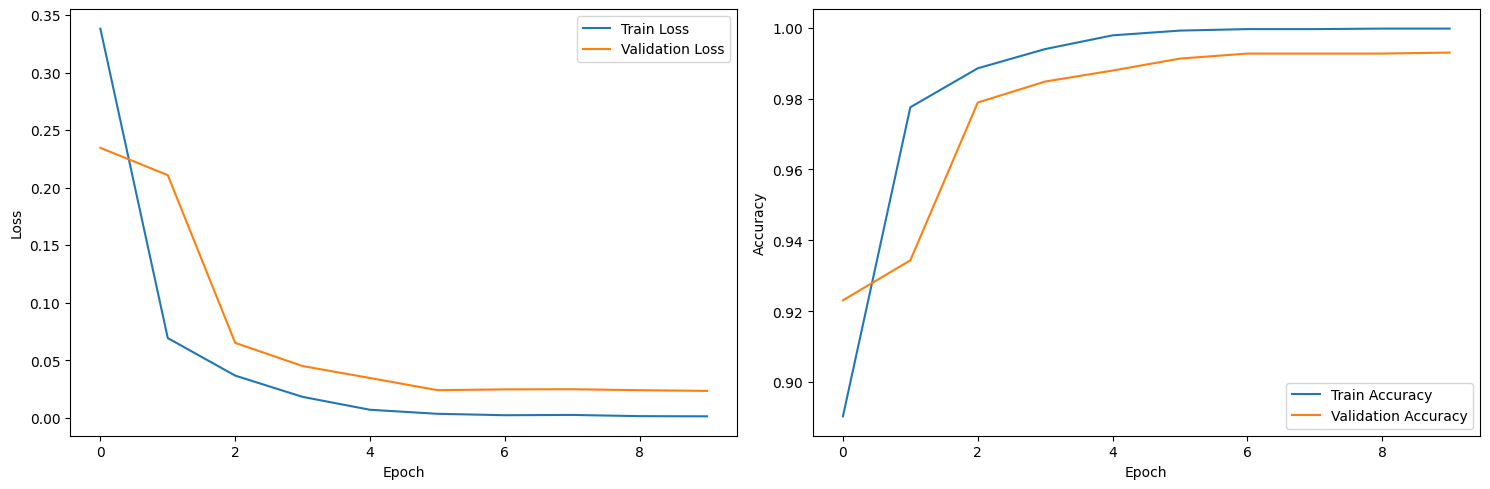

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].plot(in_history.history['loss'],label='Train Loss')
axes[0].plot(in_history.history['val_loss'],label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(in_history.history['accuracy'],label='Train Accuracy')
axes[1].plot(in_history.history['val_accuracy'],label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

In [ ]:
Ins_model=tf.keras.models.load_model('/content/model_res.keras')
Ins_model.evaluate(test_data)

139/139 ━━━━━━━━━━━━━━━━━━━━ 27s 134ms/step - accuracy: 0.9924 - loss: 0.0230


[0.025074899196624756, 0.9918919205665588]

In [ ]:
import numpy as np
from sklearn.metrics import classification_report,confusion_matrix

def predict_and_evaluate(model, test_data):
    y_true = []
    y_pred = []

    for images, labels in test_data:

        predictions = model.predict(images, verbose=0)


        true_labels = np.argmax(labels.numpy(), axis=1)
        pred_labels = np.argmax(predictions, axis=1)


        y_true.extend(true_labels)
        y_pred.extend(pred_labels)


    print("Classification Report:\n")
    print(classification_report(y_true, y_pred))

    return np.array(y_true), np.array(y_pred)

In [ ]:
y_true, y_pred = predict_and_evaluate(Ins_model, test_data)

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       444
           1       0.97      0.98      0.98       444
           2       1.00      0.99      0.99       444
           3       0.99      0.98      0.98       444
           4       1.00      1.00      1.00       444
           5       1.00      1.00      1.00       444
           6       0.99      1.00      0.99       444
           7       0.99      0.99      0.99       444
           8       1.00      0.99      0.99       444
           9       1.00      1.00      1.00       444

    accuracy                           0.99      4440
   macro avg       0.99      0.99      0.99      4440
weighted avg       0.99      0.99      0.99      4440



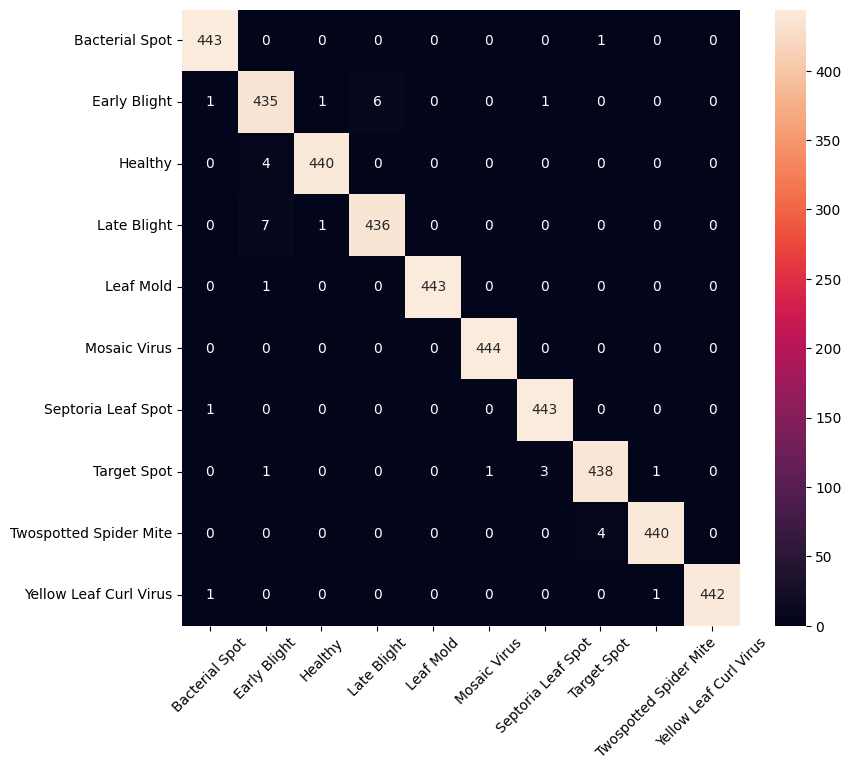

In [ ]:
class_names = ['Bacterial Spot',
'Early Blight',
'Healthy',
'Late Blight',
'Leaf Mold',
'Mosaic Virus',
'Septoria Leaf Spot',
'Target Spot',
'Twospotted Spider Mite',
'Yellow Leaf Curl Virus']
plt.figure(figsize=(9,8))
sns.heatmap(confusion_matrix(y_true,y_pred),annot=True,fmt='d',xticklabels=class_names, yticklabels=class_names)
plt.xticks(rotation=45)
plt.show()

# VGG16 (97% acc)

In [ ]:
base_model = tf.keras.applications.VGG16(weights="imagenet", include_top=False,input_shape=(255,255,3))
for layer in base_model.layers[:int(len(base_model.layers)*0.8)]:
  layer.trainable=False
inputs=tf.keras.layers.Input(shape=(255,255,3))
x = base_model(inputs)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
output = tf.keras.layers.Dense(10, activation="softmax")(x)
vgg_model = tf.keras.Model(inputs=inputs, outputs=output)
vgg_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 255, 255, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 7,146,378 (27.26 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
def lr_schedule_exp(epoch):
  if epoch<7:
    return float(tf.exp(-epoch/10.)*0.01)/2
  elif epoch<14:
    return float(tf.exp(-epoch/10.)*0.01)/3
  else:
    return float(tf.exp(-epoch/10.)*0.01)/4
schedule_vgg=tf.keras.callbacks.LearningRateScheduler(lr_schedule_exp)
check_point_vgg=tf.keras.callbacks.ModelCheckpoint('model_vgg.keras',monitor='val_accuracy',verbose=1,save_best_only=True)
early_stop_vgg=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=3,verbose=1,restore_best_weights=True,mode='max')
vgg_model.compile(loss='categorical_crossentropy',optimizer=tf.keras.optimizers.SGD(momentum=0.9,
                                                                                    nesterov=True),metrics=['accuracy'])

In [ ]:
vgg_history=vgg_model.fit(train_data,epochs=20,validation_data=validation_data,callbacks=[schedule_vgg,check_point_vgg,early_stop_vgg])

Epoch 1/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.5778 - loss: 1.2221
Epoch 1: val_accuracy improved from -inf to 0.84310, saving model to model_vgg.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 153s 335ms/step - accuracy: 0.5781 - loss: 1.2212 - val_accuracy: 0.8431 - val_loss: 0.4625 - learning_rate: 0.0050
Epoch 2/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.8833 - loss: 0.3302
Epoch 2: val_accuracy improved from 0.84310 to 0.92423, saving model to model_vgg.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 140s 316ms/step - accuracy: 0.8833 - loss: 0.3301 - val_accuracy: 0.9242 - val_loss: 0.2185 - learning_rate: 0.0045
Epoch 3/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.9258 - loss: 0.2131
Epoch 3: val_accuracy improved from 0.92423 to 0.92930, saving model to model_vgg.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 140s 316ms/step - accuracy: 0.9258 - loss: 0.2131 - val_accuracy: 0.9293 - val_loss: 0.2046 - learning_rate: 0.0041
Epoch 4/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 

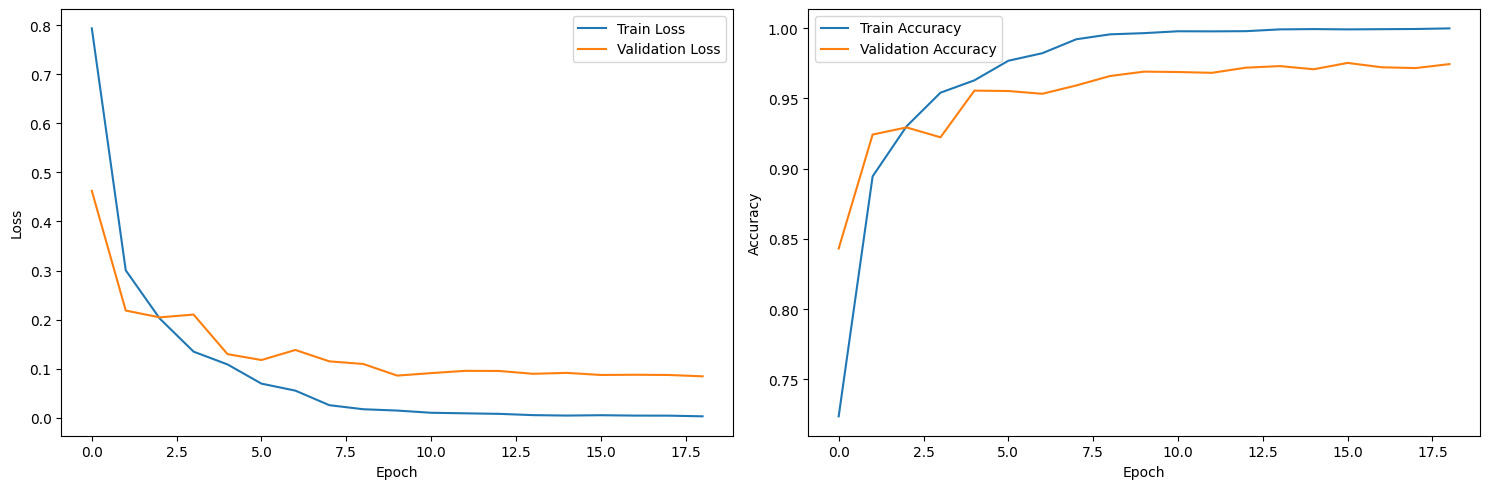

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].plot(vgg_history.history['loss'],label='Train Loss')
axes[0].plot(vgg_history.history['val_loss'],label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(vgg_history.history['accuracy'],label='Train Accuracy')
axes[1].plot(vgg_history.history['val_accuracy'],label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

In [ ]:
vgg_model=tf.keras.models.load_model('/content/model_vgg.keras')
vgg_model.evaluate(test_data)

139/139 ━━━━━━━━━━━━━━━━━━━━ 50s 353ms/step - accuracy: 0.9725 - loss: 0.0919


[0.1013350635766983, 0.9740990996360779]

_ _ _
# Data augmentation with transfer learning
_ _ _

In [ ]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
train_generator= train_datagen.flow_from_directory(
    dataset_path+'/train',
    target_size=(255,255),
    batch_size=32,
    class_mode='categorical'
)

Found 17753 images belonging to 10 classes.


# VGG16

* It improved from 97% to 98% acc

In [ ]:
base_model = tf.keras.applications.VGG16(weights="imagenet", include_top=False,input_shape=(255,255,3))
for layer in base_model.layers[:int(len(base_model.layers)*0.8)]:
  layer.trainable=False
inputs=tf.keras.layers.Input(shape=(255,255,3))
x = base_model(inputs)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
output = tf.keras.layers.Dense(10, activation="softmax")(x)
vgg_au_model = tf.keras.Model(inputs=inputs, outputs=output)
vgg_au_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 255, 255, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 7,146,378 (27.26 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
def lr_schedule_exp(epoch):
  if epoch<7:
    return float(tf.exp(-epoch/10.)*0.01)/2
  elif epoch<14:
    return float(tf.exp(-epoch/10.)*0.01)/3
  else:
    return float(tf.exp(-epoch/10.)*0.01)/4
schedule_vgg=tf.keras.callbacks.LearningRateScheduler(lr_schedule_exp)
check_point_vgg=tf.keras.callbacks.ModelCheckpoint('model_vgg_au.keras',monitor='val_accuracy',verbose=1,save_best_only=True)
early_stop_vgg=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=3,verbose=1,restore_best_weights=True,mode='max')
vgg_au_model.compile(loss='categorical_crossentropy',optimizer=tf.keras.optimizers.SGD(momentum=0.9,
                                                                                    nesterov=True),metrics=['accuracy'])

In [ ]:
vgg_history=vgg_au_model.fit(train_generator,epochs=20,validation_data=validation_data,callbacks=[schedule_vgg,check_point_vgg,early_stop_vgg])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.5732 - loss: 1.2012
Epoch 1: val_accuracy improved from -inf to 0.87211, saving model to model_vgg_au.keras
555/555 ━━━━━━━━━━━━━━━━━━━━ 382s 680ms/step - accuracy: 0.5734 - loss: 1.2004 - val_accuracy: 0.8721 - val_loss: 0.3554 - learning_rate: 0.0050
Epoch 2/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.8722 - loss: 0.3724
Epoch 2: val_accuracy improved from 0.87211 to 0.91183, saving model to model_vgg_au.keras
555/555 ━━━━━━━━━━━━━━━━━━━━ 343s 618ms/step - accuracy: 0.8722 - loss: 0.3723 - val_accuracy: 0.9118 - val_loss: 0.2669 - learning_rate: 0.0045
Epoch 3/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.9063 - loss: 0.2636
Epoch 3: val_accuracy improved from 0.91183 to 0.95127, saving model to model_vgg_au.keras
555/555 ━━━━━━━━━━━━━━━━━━━━ 357s 644ms/step - accuracy: 0.9063 - loss: 0.2636 - val_accuracy: 0.9513 - val_loss: 0.1501 - learning_rate: 0.0041
Epoch 4/20
555/555 ━━━━━━━━━━━━

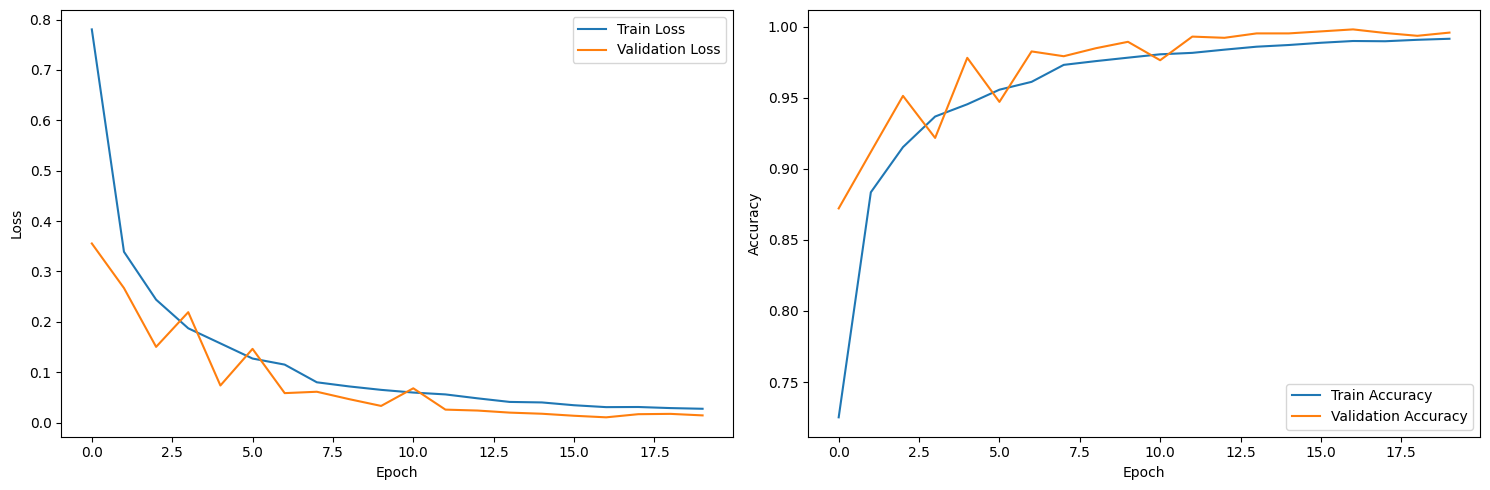

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].plot(vgg_history.history['loss'],label='Train Loss')
axes[0].plot(vgg_history.history['val_loss'],label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(vgg_history.history['accuracy'],label='Train Accuracy')
axes[1].plot(vgg_history.history['val_accuracy'],label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

In [ ]:
vgg_au_model=tf.keras.models.load_model('/content/model_vgg_au.keras')
vgg_au_model.evaluate(test_data)

139/139 ━━━━━━━━━━━━━━━━━━━━ 35s 241ms/step - accuracy: 0.9834 - loss: 0.0530


[0.0604371577501297, 0.9813063144683838]

In [ ]:
y_true, y_pred = predict_and_evaluate(vgg_au_model, test_data)

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       444
           1       0.97      0.96      0.96       444
           2       0.98      0.97      0.98       444
           3       0.96      0.98      0.97       444
           4       0.99      1.00      0.99       444
           5       1.00      1.00      1.00       444
           6       0.98      0.98      0.98       444
           7       0.99      0.96      0.97       444
           8       0.97      0.99      0.98       444
           9       0.99      1.00      1.00       444

    accuracy                           0.98      4440
   macro avg       0.98      0.98      0.98      4440
weighted avg       0.98      0.98      0.98      4440



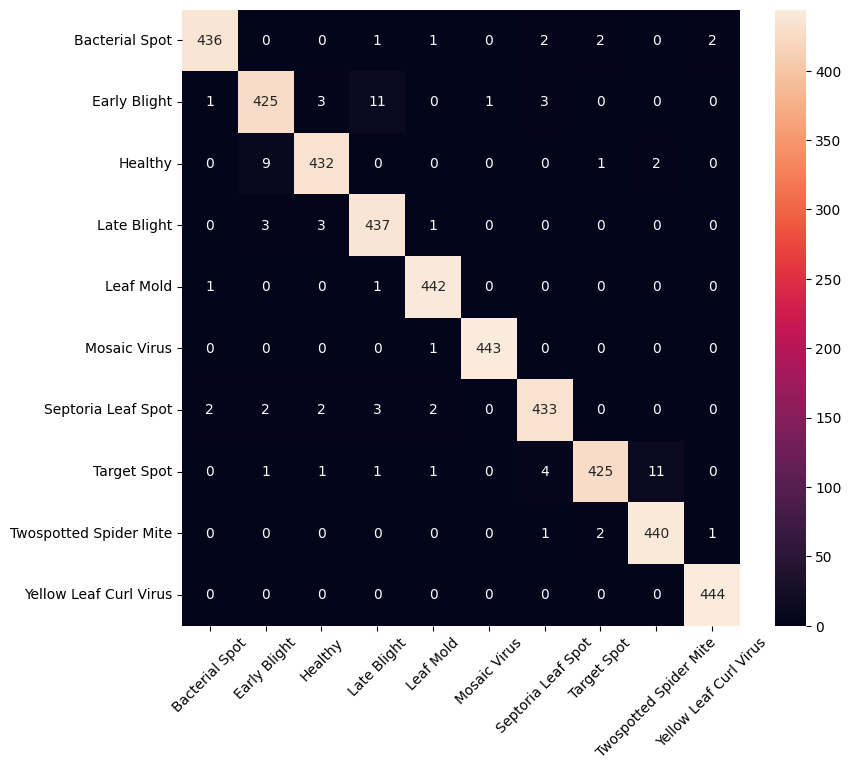

In [ ]:
class_names = ['Bacterial Spot',
'Early Blight',
'Healthy',
'Late Blight',
'Leaf Mold',
'Mosaic Virus',
'Septoria Leaf Spot',
'Target Spot',
'Twospotted Spider Mite',
'Yellow Leaf Curl Virus']
plt.figure(figsize=(9,8))
sns.heatmap(confusion_matrix(y_true,y_pred),annot=True,fmt='d',xticklabels=class_names, yticklabels=class_names)
plt.xticks(rotation=45)
plt.show()

# ResNet

In [ ]:


base_model = tf.keras.applications.ResNet50(weights="imagenet", include_top=False, input_shape=(255, 255, 3))
for layer in base_model.layers[:int(len(base_model.layers)*0.8)]:
  layer.trainable=False
inputs=tf.keras.layers.Input(shape=(255,255,3))

x = base_model(inputs)



x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
output = tf.keras.layers.Dense(10, activation="softmax")(x)
Res_au_model = tf.keras.Model(inputs=inputs, outputs=output)
Res_au_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 255, 255, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 15,241,610 (58.14 MB)

 Non-trainable params: 8,609,664 (32.84 MB)

In [ ]:
def lr_schedule_exp(epoch):
    return float(tf.exp(-epoch/10.)*0.01)
schedule_res=tf.keras.callbacks.LearningRateScheduler(lr_schedule_exp)
check_point_res=tf.keras.callbacks.ModelCheckpoint('model_res.keras',monitor='val_accuracy',verbose=1,save_best_only=True)
early_stop_res=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=5,verbose=1,restore_best_weights=True,mode='max')

In [ ]:
Res_au_model.compile(loss='categorical_crossentropy',optimizer=tf.keras.optimizers.SGD(momentum=0.9,
                                                                                    nesterov=True),metrics=['accuracy'])

In [ ]:
res_au_history=Res_au_model.fit(train_generator,epochs=20,validation_data=validation_data,callbacks=[schedule_res,check_point_res,early_stop_res])

Epoch 1/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.4047 - loss: 1.6918
Epoch 1: val_accuracy improved from -inf to 0.27549, saving model to model_res.keras
555/555 ━━━━━━━━━━━━━━━━━━━━ 342s 586ms/step - accuracy: 0.4048 - loss: 1.6915 - val_accuracy: 0.2755 - val_loss: 18.6947 - learning_rate: 0.0100
Epoch 2/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.5475 - loss: 1.2675
Epoch 2: val_accuracy improved from 0.27549 to 0.44676, saving model to model_res.keras
555/555 ━━━━━━━━━━━━━━━━━━━━ 363s 565ms/step - accuracy: 0.5475 - loss: 1.2674 - val_accuracy: 0.4468 - val_loss: 1.5978 - learning_rate: 0.0090
Epoch 3/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.6015 - loss: 1.1083
Epoch 3: val_accuracy did not improve from 0.44676
555/555 ━━━━━━━━━━━━━━━━━━━━ 313s 563ms/step - accuracy: 0.6015 - loss: 1.1083 - val_accuracy: 0.3563 - val_loss: 4.0206 - learning_rate: 0.0082
Epoch 4/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.6397 - l

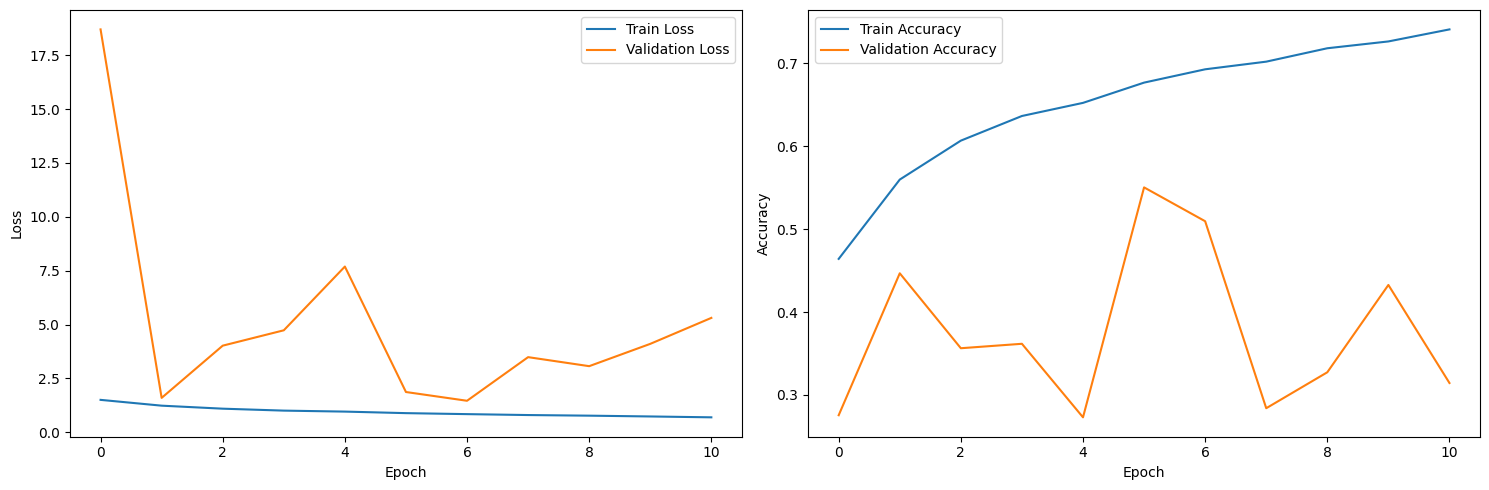

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].plot(res_au_history.history['loss'],label='Train Loss')
axes[0].plot(res_au_history.history['val_loss'],label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(res_au_history.history['accuracy'],label='Train Accuracy')
axes[1].plot(res_au_history.history['val_accuracy'],label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

In [ ]:
Res_au_model=tf.keras.models.load_model('/content/model_res.keras')
Res_au_model.evaluate(test_data)

139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 125ms/step - accuracy: 0.4916 - loss: 2.0429


[2.0442018508911133, 0.4905405342578888]

# Inceprion V3
* No improvment

In [ ]:
base_model_2=tf.keras.applications.InceptionV3(weights='imagenet',include_top=False, input_shape=(255, 255, 3))
for layer in base_model_2.layers[:int(len(base_model_2.layers)*0.8)]:
  layer.trainable=False

inputs=tf.keras.layers.Input(shape=(255,255,3))

x = base_model_2(inputs)



x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(500, activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
output = tf.keras.layers.Dense(10, activation="softmax")(x)
Inc_au_model = tf.keras.Model(inputs=inputs, outputs=output)
Inc_au_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 255, 255, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 6, 6, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 500)            │     1,024,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,832,294 (87.10 MB)

 Trainable params: 12,144,390 (46.33 MB)

 Non-trainable params: 10,687,904 (40.77 MB)

In [ ]:
def lr_schedule_exp(epoch):
  if epoch<4:
    return float(tf.exp(-epoch/10.)*0.01)
  elif epoch<8:
    return float(tf.exp(-epoch/10.)*0.01)/2
  else:
    return float(tf.exp(-epoch/10.)*0.01)/4
schedule_In=tf.keras.callbacks.LearningRateScheduler(lr_schedule_exp)
check_point_In=tf.keras.callbacks.ModelCheckpoint('model_In_aug.keras',monitor='val_accuracy',verbose=1,save_best_only=True)
early_stop_In=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=3,verbose=1,restore_best_weights=True,mode='max')

In [ ]:
Inc_au_model.compile(loss='categorical_crossentropy',optimizer=tf.keras.optimizers.SGD(momentum=0.9,
                                                                                    nesterov=True),metrics=['accuracy'])

In [ ]:
in_history=Inc_au_model.fit(train_generator,epochs=20,validation_data=validation_data,callbacks=[schedule_In,check_point_In,early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.6980 - loss: 0.8786
Epoch 1: val_accuracy improved from -inf to 0.93014, saving model to model_In_aug.keras
555/555 ━━━━━━━━━━━━━━━━━━━━ 342s 570ms/step - accuracy: 0.6983 - loss: 0.8780 - val_accuracy: 0.9301 - val_loss: 0.1990 - learning_rate: 0.0033
Epoch 2/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.9289 - loss: 0.2015
Epoch 2: val_accuracy improved from 0.93014 to 0.95493, saving model to model_In_aug.keras
555/555 ━━━━━━━━━━━━━━━━━━━━ 340s 522ms/step - accuracy: 0.9289 - loss: 0.2015 - val_accuracy: 0.9549 - val_loss: 0.1274 - learning_rate: 0.0030
Epoch 3/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.9529 - loss: 0.1384
Epoch 3: val_accuracy improved from 0.95493 to 0.97183, saving model to model_In_aug.keras
555/555 ━━━━━━━━━━━━━━━━━━━━ 307s 552ms/step - accuracy: 0.9529 - loss: 0.1384 - val_accuracy: 0.9718 - val_loss: 0.0821 - learning_rate: 0.0027
Epoch 4/20
555/555 ━━━━━━━━━━━━

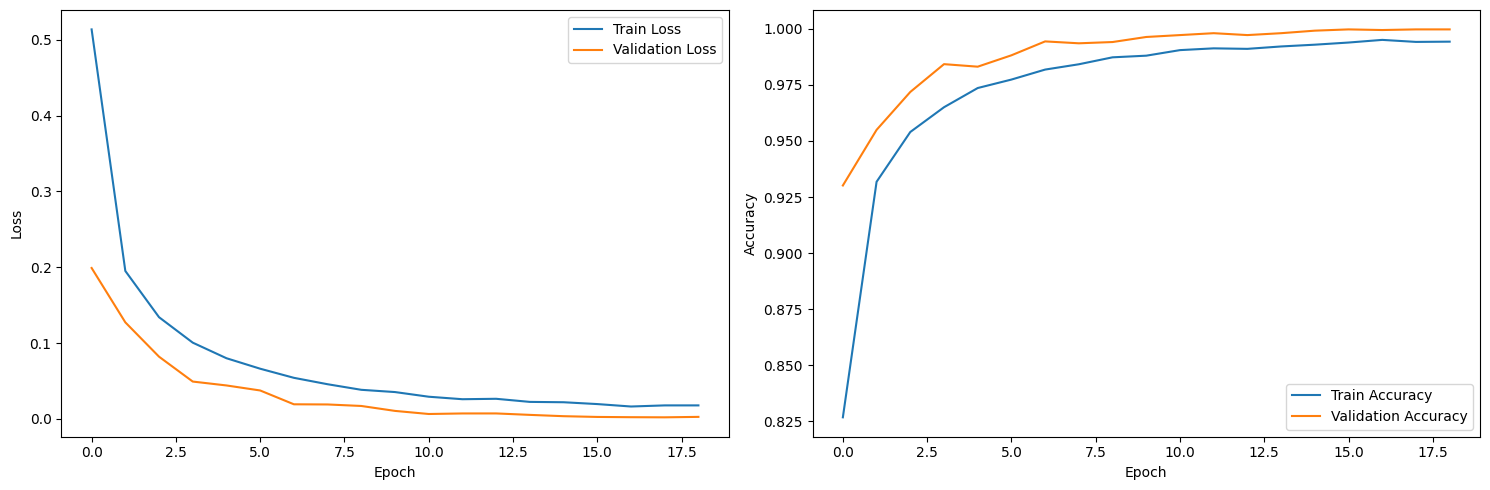

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].plot(in_history.history['loss'],label='Train Loss')
axes[0].plot(in_history.history['val_loss'],label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(in_history.history['accuracy'],label='Train Accuracy')
axes[1].plot(in_history.history['val_accuracy'],label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

In [ ]:
Inc_au_model=tf.keras.models.load_model('/content/model_In_aug.keras')
Inc_au_model.evaluate(test_data)

139/139 ━━━━━━━━━━━━━━━━━━━━ 23s 104ms/step - accuracy: 0.9810 - loss: 0.0572


[0.05355621129274368, 0.9833333492279053]

In [ ]:
import numpy as np
from sklearn.metrics import classification_report,confusion_matrix

def predict_and_evaluate(model, test_data):
    y_true = []
    y_pred = []

    for images, labels in test_data:

        predictions = model.predict(images, verbose=0)


        true_labels = np.argmax(labels.numpy(), axis=1)
        pred_labels = np.argmax(predictions, axis=1)


        y_true.extend(true_labels)
        y_pred.extend(pred_labels)


    print("Classification Report:\n")
    print(classification_report(y_true, y_pred))

    return np.array(y_true), np.array(y_pred)

In [ ]:
y_true, y_pred = predict_and_evaluate(Inc_au_model, test_data)

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       444
           1       0.98      0.97      0.97       444
           2       0.99      0.99      0.99       444
           3       0.98      0.98      0.98       444
           4       0.98      0.98      0.98       444
           5       1.00      1.00      1.00       444
           6       0.97      0.98      0.98       444
           7       0.98      0.95      0.96       444
           8       0.96      1.00      0.98       444
           9       1.00      1.00      1.00       444

    accuracy                           0.98      4440
   macro avg       0.98      0.98      0.98      4440
weighted avg       0.98      0.98      0.98      4440



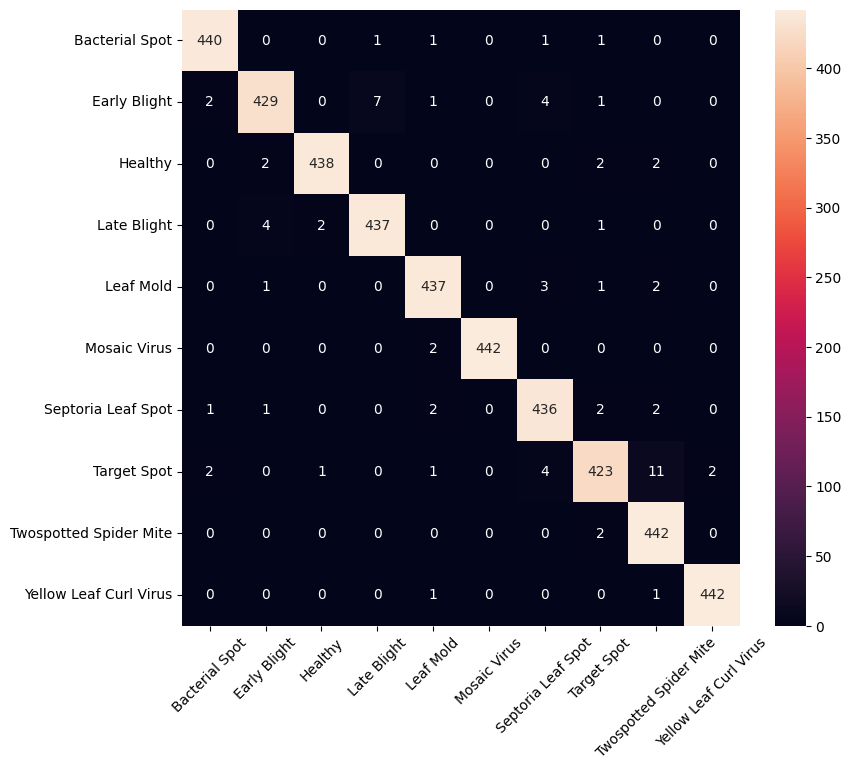

In [ ]:
class_names = ['Bacterial Spot',
'Early Blight',
'Healthy',
'Late Blight',
'Leaf Mold',
'Mosaic Virus',
'Septoria Leaf Spot',
'Target Spot',
'Twospotted Spider Mite',
'Yellow Leaf Curl Virus']
plt.figure(figsize=(9,8))
sns.heatmap(confusion_matrix(y_true,y_pred),annot=True,fmt='d',xticklabels=class_names, yticklabels=class_names)
plt.xticks(rotation=45)
plt.show()

# Data Augmentation In My Best Custom model_4
* It improved from 98.7% to 99% acc

In [ ]:

@tf.keras.utils.register_keras_serializable()
class Recalibration_block(tf.keras.layers.Layer):
    def __init__(self, filters, activation='relu', **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.activation = activation


        self.gap = tf.keras.layers.GlobalAveragePooling2D()
        self.dense1 = tf.keras.layers.Dense(units=filters // 16, activation=activation)
        self.dense2 = tf.keras.layers.Dense(units=filters, activation='sigmoid')
        self.reshape = tf.keras.layers.Reshape((1, 1, filters))

    def build(self, input_shape):

        self.gap.build(input_shape)
        gap_shape = self.gap.compute_output_shape(input_shape)

        self.dense1.build(gap_shape)
        dense1_shape = self.dense1.compute_output_shape(gap_shape)

        self.dense2.build(dense1_shape)
        dense2_shape = self.dense2.compute_output_shape(dense1_shape)

        self.reshape.build(dense2_shape)


        super().build(input_shape)

    def call(self, inputs):
        x = self.gap(inputs)
        x = self.dense1(x)
        x = self.dense2(x)
        x = self.reshape(x)
        return tf.multiply(inputs, x)

    def get_config(self):
        config = super().get_config()
        config.update({
            "filters": self.filters,
            "activation": self.activation,
        })
        return config
from functools import partial
Conv2d=partial(tf.keras.layers.Conv2D,kernel_size=3,padding='same',strides=1 )
@tf.keras.utils.register_keras_serializable()
class Inception_mode(tf.keras.layers.Layer):
  def __init__ (self,filters,strides=1,activation='relu',**kwargs):
    super().__init__(**kwargs)
    self.filters=filters
    self.strides=strides
    self.activation=activation
    self.concat = tf.keras.layers.Concatenate(axis=-1)

    self.inception_layers_1=[tf.keras.layers.MaxPooling2D(pool_size=2,strides=strides,padding='same'),
                             Conv2d(filters=filters,activation=activation),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters)]

    self.inception_layers_2=[tf.keras.layers.AveragePooling2D(pool_size=2,strides=strides,padding='same'),
                             Conv2d(filters=filters),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters)]

    self.inception_layers_3=[Conv2d(filters=filters,strides=strides,activation=activation,kernel_size=1),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters,kernel_size=1)]




  def build(self, input_shape):
      input_shape = list(input_shape)
      input_shape[0] = 1
      input_shape = tuple(input_shape)

      dummy = tf.keras.backend.zeros(input_shape)
      _ = self.call(dummy)
      super().build(input_shape)


  def call(self, inputs):
      def apply_layers(x, layer_list):
          for layer in layer_list:
              x = layer(x)
          return x

      x1 = apply_layers(inputs, self.inception_layers_1)
      x2 = apply_layers(inputs, self.inception_layers_2)
      x3 = apply_layers(inputs, self.inception_layers_3)

      return self.concat([x1, x2, x3])

  def get_config(self):
    config = super().get_config()
    config.update({
        "filters": self.filters,
        "strides": self.strides,
        "activation": self.activation
    })
    return config

In [ ]:
inputs=tf.keras.layers.Input(shape=(255,255,3))
max=tf.keras.layers.MaxPool2D(pool_size=(2,2))(inputs)
in_block_1=Inception_mode(filters=68)(max)
recal_1=Recalibration_block(filters=in_block_1.shape[-1])(in_block_1)
conv_1=tf.keras.layers.Conv2D(filters=204,kernel_size=3,padding='valid',activation='relu',strides=2)(recal_1)
recal_2=Recalibration_block(filters=conv_1.shape[-1])(conv_1)
in_block_2=Inception_mode(filters=128)(recal_2)
conv_2=tf.keras.layers.Conv2D(filters=384,kernel_size=2,padding='same',activation='relu',strides=1)(in_block_2)
recal_3=Recalibration_block(filters=conv_2.shape[-1])(conv_2)
layer_5=tf.keras.layers.GlobalMaxPooling2D()(recal_3)
outputs=tf.keras.layers.Dense(10,activation='softmax')(layer_5)

model_4=tf.keras.Model(inputs=inputs,outputs=outputs)








model_4.summary()
model_4.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9,nesterov=True),loss='categorical_crossentropy',metrics=['accuracy'])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 255, 255, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_mode (Inception_mode) │ (None, 127, 127, 204)  │        92,956 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ recalibration_block             │ (None, 127, 127, 204)  │         5,112 │
│ (Recalibration_block)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 63, 63, 204)    │       374,748 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ recalibration_block_1           │ (None, 63, 63, 204)    │         5,112 │
│ (Recalibration_block)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_mode_1                │ (None, 63, 63, 384)    │       809,728 │
│ (Inception_mode)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 63, 63, 384)    │       590,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ recalibration_block_2           │ (None, 63, 63, 384)    │        18,840 │
│ (Recalibration_block)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 384)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         3,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,900,554 (7.25 MB)

 Trainable params: 1,899,378 (7.25 MB)

 Non-trainable params: 1,176 (4.59 KB)

In [ ]:
def lr_schedule_exp(epoch):
  if epoch<4:
    return float(tf.exp(-epoch/10.)*0.01)
  elif epoch<8:
    return float(tf.exp(-epoch/10.)*0.01)/2
  else:
    return float(tf.exp(-epoch/10.)*0.01)/3

schedule_4=tf.keras.callbacks.LearningRateScheduler(lr_schedule_exp)
check_point_4=tf.keras.callbacks.ModelCheckpoint('model_4_best.keras',monitor='val_accuracy',verbose=1,save_best_only=True,mode='max')
early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=3,verbose=1,restore_best_weights=True,mode='max')

In [ ]:
history_4=model_4.fit(train_generator,epochs=20,validation_data=(validation_data),callbacks=[schedule_4,check_point_4,early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - accuracy: 0.5888 - loss: 1.4285
Epoch 1: val_accuracy improved from -inf to 0.74197, saving model to model_4_best.keras
555/555 ━━━━━━━━━━━━━━━━━━━━ 499s 836ms/step - accuracy: 0.5891 - loss: 1.4274 - val_accuracy: 0.7420 - val_loss: 0.7818 - learning_rate: 0.0100
Epoch 2/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - accuracy: 0.8906 - loss: 0.3152
Epoch 2: val_accuracy did not improve from 0.74197
555/555 ━━━━━━━━━━━━━━━━━━━━ 395s 712ms/step - accuracy: 0.8906 - loss: 0.3152 - val_accuracy: 0.6569 - val_loss: 1.1146 - learning_rate: 0.0090
Epoch 3/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.9282 - loss: 0.2025
Epoch 3: val_accuracy improved from 0.74197 to 0.86873, saving model to model_4_best.keras
555/555 ━━━━━━━━━━━━━━━━━━━━ 398s 716ms/step - accuracy: 0.9282 - loss: 0.2025 - val_accuracy: 0.8687 - val_loss: 0.4409 - learning_rate: 0.0082
Epoch 4/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - accuracy: 0.948

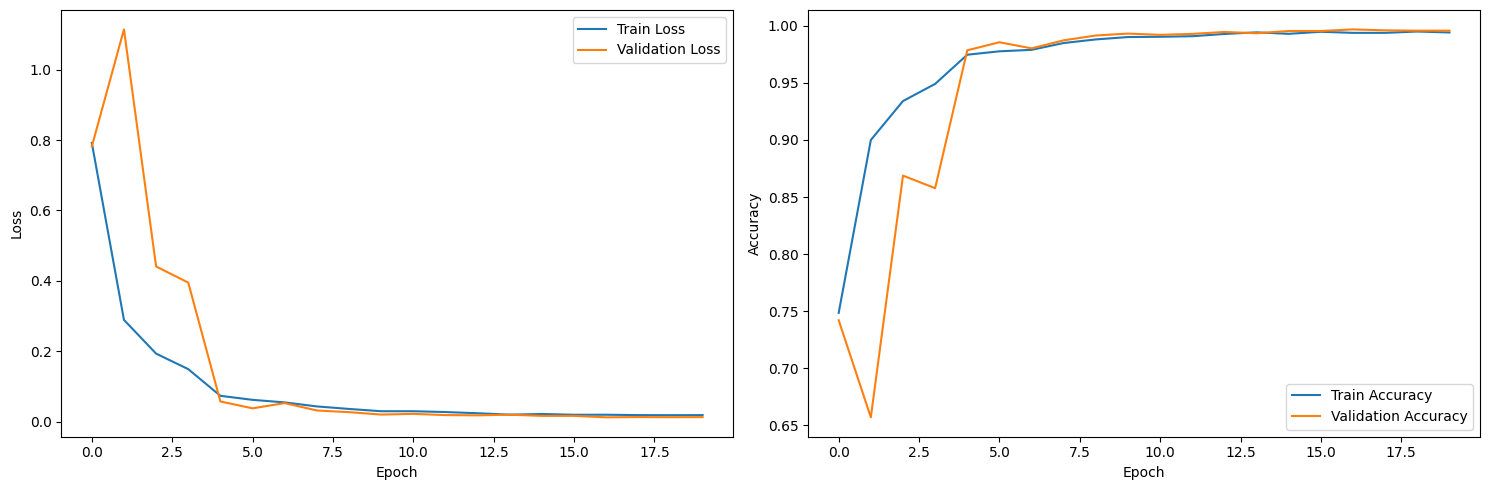

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].plot(history_4.history['loss'],label='Train Loss')
axes[0].plot(history_4.history['val_loss'],label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_4.history['accuracy'],label='Train Accuracy')
axes[1].plot(history_4.history['val_accuracy'],label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

In [ ]:
model_4=tf.keras.models.load_model('/content/model_4_best.keras')
model_4.evaluate(test_data)

139/139 ━━━━━━━━━━━━━━━━━━━━ 34s 231ms/step - accuracy: 0.9909 - loss: 0.0312


[0.0332854799926281, 0.989414393901825]

In [ ]:
y_true, y_pred = predict_and_evaluate(model_4, test_data)

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       444
           1       0.97      0.99      0.98       444
           2       1.00      1.00      1.00       444
           3       0.99      0.97      0.98       444
           4       1.00      1.00      1.00       444
           5       1.00      1.00      1.00       444
           6       1.00      0.99      0.99       444
           7       0.99      0.97      0.98       444
           8       0.98      0.99      0.98       444
           9       0.99      1.00      0.99       444

    accuracy                           0.99      4440
   macro avg       0.99      0.99      0.99      4440
weighted avg       0.99      0.99      0.99      4440



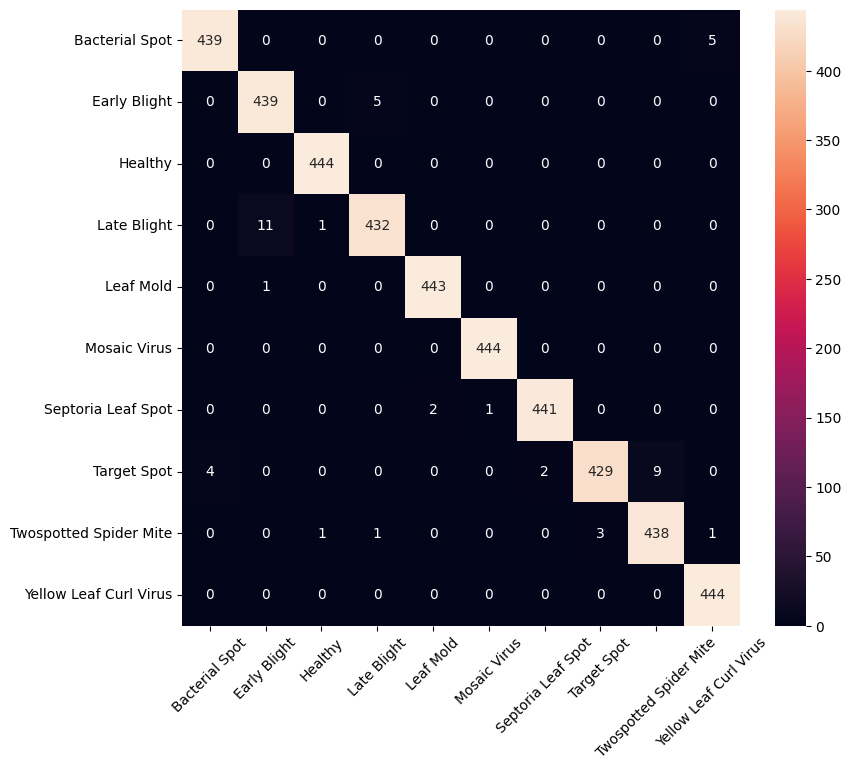

In [ ]:
class_names = ['Bacterial Spot',
'Early Blight',
'Healthy',
'Late Blight',
'Leaf Mold',
'Mosaic Virus',
'Septoria Leaf Spot',
'Target Spot',
'Twospotted Spider Mite',
'Yellow Leaf Curl Virus']
plt.figure(figsize=(9,8))
sns.heatmap(confusion_matrix(y_true,y_pred),annot=True,fmt='d',xticklabels=class_names, yticklabels=class_names)
plt.xticks(rotation=45)
plt.show()

_ _ _
# (Some Extra) Let's make our data balanced
_ _ _

In [18]:
import random
import shutil
from pathlib import Path

original_dir = dataset_path+'/train/'
balanced_dir = 'balanced_dataset/train'
samples_per_class = 1000
random.seed(1)

os.makedirs(balanced_dir, exist_ok=True)

for class_name in os.listdir(original_dir):
    class_path = os.path.join(original_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    random.shuffle(images)
    selected_images = images[:samples_per_class]

    new_class_path = os.path.join(balanced_dir, class_name)
    os.makedirs(new_class_path, exist_ok=True)

    for img_name in selected_images:
        src = os.path.join(class_path, img_name)
        dst = os.path.join(new_class_path, img_name)
        shutil.copy2(src, dst)

print("Balanced dataset created.")


Balanced dataset created.


In [19]:
train_data,validation_data=tf.keras.preprocessing.image_dataset_from_directory(directory=balanced_dir,
                                                               image_size=(255,255),batch_size=32,
                                                               label_mode='categorical',shuffle=True,
                                                              validation_split=0.2,subset='both',seed=1)

Found 10000 files belonging to 10 classes.
Using 8000 files for training.
Using 2000 files for validation.


In [20]:
train_data=train_data.map(lambda x,y:(x/255,y) )
validation_data=validation_data.map(lambda x,y:(x/255,y) )

# Let's Test Our Top Custom Model In The New Balanced Data (98.6% acc)

In [31]:

@tf.keras.utils.register_keras_serializable()
class Recalibration_block(tf.keras.layers.Layer):
    def __init__(self, filters, activation='relu', **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.activation = activation


        self.gap = tf.keras.layers.GlobalAveragePooling2D()
        self.dense1 = tf.keras.layers.Dense(units=filters // 16, activation=activation)
        self.dense2 = tf.keras.layers.Dense(units=filters, activation='sigmoid')
        self.reshape = tf.keras.layers.Reshape((1, 1, filters))

    def build(self, input_shape):

        self.gap.build(input_shape)
        gap_shape = self.gap.compute_output_shape(input_shape)

        self.dense1.build(gap_shape)
        dense1_shape = self.dense1.compute_output_shape(gap_shape)

        self.dense2.build(dense1_shape)
        dense2_shape = self.dense2.compute_output_shape(dense1_shape)

        self.reshape.build(dense2_shape)


        super().build(input_shape)

    def call(self, inputs):
        x = self.gap(inputs)
        x = self.dense1(x)
        x = self.dense2(x)
        x = self.reshape(x)
        return tf.multiply(inputs, x)

    def get_config(self):
        config = super().get_config()
        config.update({
            "filters": self.filters,
            "activation": self.activation,
        })
        return config

from functools import partial
Conv2d=partial(tf.keras.layers.Conv2D,kernel_size=3,padding='same',strides=1 )
@tf.keras.utils.register_keras_serializable()
class Inception_mode(tf.keras.layers.Layer):
  def __init__ (self,filters,strides=1,activation='relu',**kwargs):
    super().__init__(**kwargs)
    self.filters=filters
    self.strides=strides
    self.activation=activation
    self.concat = tf.keras.layers.Concatenate(axis=-1)

    self.inception_layers_1=[tf.keras.layers.MaxPooling2D(pool_size=2,strides=strides,padding='same'),
                             Conv2d(filters=filters,activation=activation),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters)]

    self.inception_layers_2=[tf.keras.layers.AveragePooling2D(pool_size=2,strides=strides,padding='same'),
                             Conv2d(filters=filters),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters)]

    self.inception_layers_3=[Conv2d(filters=filters,strides=strides,activation=activation,kernel_size=1),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters,kernel_size=1)]




  def build(self, input_shape):
      input_shape = list(input_shape)
      input_shape[0] = 1
      input_shape = tuple(input_shape)

      dummy = tf.keras.backend.zeros(input_shape)
      _ = self.call(dummy)
      super().build(input_shape)


  def call(self, inputs):
      def apply_layers(x, layer_list):
          for layer in layer_list:
              x = layer(x)
          return x

      x1 = apply_layers(inputs, self.inception_layers_1)
      x2 = apply_layers(inputs, self.inception_layers_2)
      x3 = apply_layers(inputs, self.inception_layers_3)

      return self.concat([x1, x2, x3])

  def get_config(self):
    config = super().get_config()
    config.update({
        "filters": self.filters,
        "strides": self.strides,
        "activation": self.activation
    })
    return config

In [32]:
inputs=tf.keras.layers.Input(shape=(255,255,3))
max=tf.keras.layers.MaxPool2D(pool_size=(2,2))(inputs)
in_block_1=Inception_mode(filters=68)(max)
recal_1=Recalibration_block(filters=in_block_1.shape[-1])(in_block_1)
conv_1=tf.keras.layers.Conv2D(filters=204,kernel_size=3,padding='valid',activation='relu',strides=2)(recal_1)
recal_2=Recalibration_block(filters=conv_1.shape[-1])(conv_1)
in_block_2=Inception_mode(filters=128)(recal_2)
conv_2=tf.keras.layers.Conv2D(filters=384,kernel_size=2,padding='same',activation='relu',strides=1)(in_block_2)
recal_3=Recalibration_block(filters=conv_2.shape[-1])(conv_2)
layer_5=tf.keras.layers.GlobalMaxPooling2D()(recal_3)
outputs=tf.keras.layers.Dense(10,activation='softmax')(layer_5)

model_4=tf.keras.Model(inputs=inputs,outputs=outputs)








model_4.summary()
model_4.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9,nesterov=True),loss='categorical_crossentropy',metrics=['accuracy'])

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 255, 255, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 127, 127, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_mode (Inception_mode) │ (None, 127, 127, 204)  │        92,956 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ recalibration_block             │ (None, 127, 127, 204)  │         5,112 │
│ (Recalibration_block)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_194 (Conv2D)             │ (None, 63, 63, 204)    │       374,748 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ recalibration_block_1           │ (None, 63, 63, 204)    │         5,112 │
│ (Recalibration_block)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_mode_1                │ (None, 63, 63, 384)    │       809,728 │
│ (Inception_mode)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_201 (Conv2D)             │ (None, 63, 63, 384)    │       590,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ recalibration_block_2           │ (None, 63, 63, 384)    │        18,840 │
│ (Recalibration_block)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 384)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         3,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,900,554 (7.25 MB)

 Trainable params: 1,899,378 (7.25 MB)

 Non-trainable params: 1,176 (4.59 KB)

In [33]:
def lr_schedule_exp(epoch):
  if epoch<7:
    return float(tf.exp(-epoch/10.)*0.01)/2
  elif epoch<14:
    return float(tf.exp(-epoch/10.)*0.01)/3
  else:
    return float(tf.exp(-epoch/10.)*0.01)/4

schedule_4=tf.keras.callbacks.LearningRateScheduler(lr_schedule_exp)
check_point_4=tf.keras.callbacks.ModelCheckpoint('model_4_best.keras',monitor='val_accuracy',verbose=1,save_best_only=True,mode='max')
early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=5,verbose=1,restore_best_weights=True,mode='max')

In [34]:
history_4=model_4.fit(train_data,epochs=20,validation_data=(validation_data),callbacks=[schedule_4,check_point_4,early_stop])

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.5073 - loss: 1.4692
Epoch 1: val_accuracy improved from -inf to 0.20100, saving model to model_4_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 194s 637ms/step - accuracy: 0.5080 - loss: 1.4671 - val_accuracy: 0.2010 - val_loss: 4.8606 - learning_rate: 0.0050
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - accuracy: 0.8599 - loss: 0.4017
Epoch 2: val_accuracy improved from 0.20100 to 0.38750, saving model to model_4_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 143s 571ms/step - accuracy: 0.8599 - loss: 0.4015 - val_accuracy: 0.3875 - val_loss: 2.0735 - learning_rate: 0.0045
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - accuracy: 0.9083 - loss: 0.2614
Epoch 3: val_accuracy improved from 0.38750 to 0.89400, saving model to model_4_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 143s 571ms/step - accuracy: 0.9083 - loss: 0.2614 - val_accuracy: 0.8940 - val_loss: 0.3144 - learning_rate: 0.0041
Epoch 4/20
250/250 ━━━━━━━━━━━━

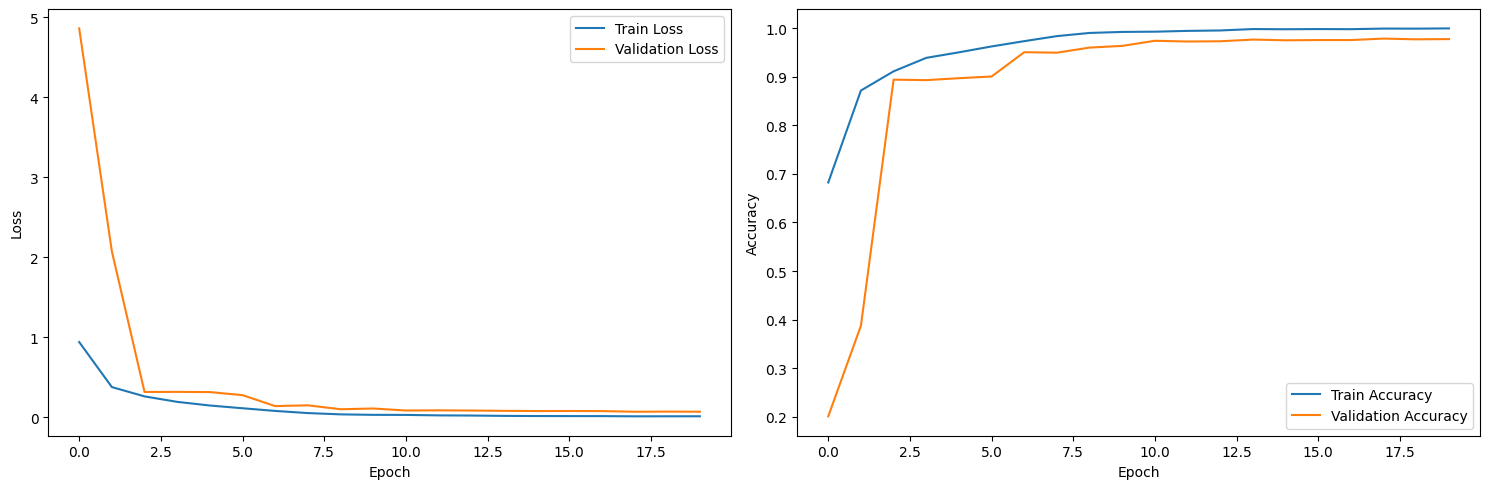

In [35]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].plot(history_4.history['loss'],label='Train Loss')
axes[0].plot(history_4.history['val_loss'],label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_4.history['accuracy'],label='Train Accuracy')
axes[1].plot(history_4.history['val_accuracy'],label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

In [36]:
model_4=tf.keras.models.load_model('/content/model_4_best.keras')
model_4.evaluate(test_data)

139/139 ━━━━━━━━━━━━━━━━━━━━ 33s 220ms/step - accuracy: 0.9863 - loss: 0.0523


[0.0569014810025692, 0.9831081032752991]

# Let's Also Try Inception V3 In The New Data (98.6% acc)

In [22]:
base_model_2=tf.keras.applications.InceptionV3(weights='imagenet',include_top=False, input_shape=(255, 255, 3))
for layer in base_model_2.layers[:int(len(base_model_2.layers)*0.2)]:
  layer.trainable=False

inputs=tf.keras.layers.Input(shape=(255,255,3))

x = base_model_2(inputs)



x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(500, activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
output = tf.keras.layers.Dense(10, activation="softmax")(x)
Inc_model = tf.keras.Model(inputs=inputs, outputs=output)
Inc_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 255, 255, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 6, 6, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 500)            │     1,024,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,832,294 (87.10 MB)

 Trainable params: 22,093,174 (84.28 MB)

 Non-trainable params: 739,120 (2.82 MB)

In [26]:
def lr_schedule_exp(epoch):
  if epoch<4:
    return float(tf.exp(-epoch/10.)*0.01)
  elif epoch<8:
    return float(tf.exp(-epoch/10.)*0.01)/2
  else:
    return float(tf.exp(-epoch/10.)*0.01)/4
schedule_In=tf.keras.callbacks.LearningRateScheduler(lr_schedule_exp)
check_point_In=tf.keras.callbacks.ModelCheckpoint('model_inc.keras',monitor='val_accuracy',verbose=1,save_best_only=True)
early_stop_In=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=3,verbose=1,restore_best_weights=True,mode='max')

In [27]:
Inc_model.compile(loss='categorical_crossentropy',optimizer=tf.keras.optimizers.SGD(momentum=0.9,nesterov=True),metrics=['accuracy'])

In [28]:
in_history=Inc_model.fit(train_data,epochs=20,validation_data=validation_data,callbacks=[schedule_In,check_point_In,early_stop_In])

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.7154 - loss: 0.8582
Epoch 1: val_accuracy improved from -inf to 0.89050, saving model to model_inc.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 140s 303ms/step - accuracy: 0.7159 - loss: 0.8567 - val_accuracy: 0.8905 - val_loss: 0.3421 - learning_rate: 0.0100
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.9624 - loss: 0.1217
Epoch 2: val_accuracy improved from 0.89050 to 0.95100, saving model to model_inc.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 92s 236ms/step - accuracy: 0.9624 - loss: 0.1216 - val_accuracy: 0.9510 - val_loss: 0.1558 - learning_rate: 0.0090
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9800 - loss: 0.0565
Epoch 3: val_accuracy improved from 0.95100 to 0.97200, saving model to model_inc.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 83s 239ms/step - accuracy: 0.9800 - loss: 0.0564 - val_accuracy: 0.9720 - val_loss: 0.0906 - learning_rate: 0.0082
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s

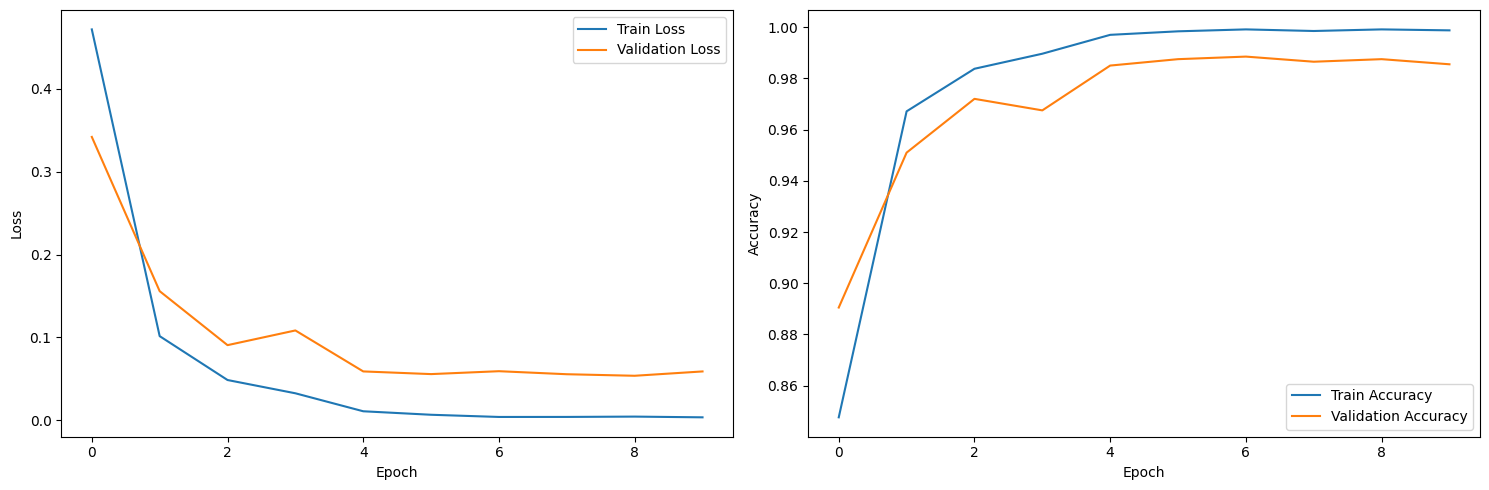

In [29]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].plot(in_history.history['loss'],label='Train Loss')
axes[0].plot(in_history.history['val_loss'],label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(in_history.history['accuracy'],label='Train Accuracy')
axes[1].plot(in_history.history['val_accuracy'],label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

In [30]:
Inc_model=tf.keras.models.load_model('/content/model_inc.keras')
Inc_model.evaluate(test_data)

139/139 ━━━━━━━━━━━━━━━━━━━━ 27s 136ms/step - accuracy: 0.9862 - loss: 0.0549


[0.06162392720580101, 0.9860360622406006]

_ _ _
# Let's Make A Web App
_ _ _

In [37]:
!rm -rf /root/.ngrok2
!rm -rf /root/.config/ngrok
!rm -rf ~/.ngrok2
!rm -rf ~/.config/ngrok


In [38]:
!pip uninstall -y pyngrok
!pip install pyngrok --upgrade


In [39]:

!pip install -q streamlit pyngrok

with open("app.py", "w") as f:
    f.write('''

import streamlit as st
import numpy as np
from PIL import Image
import tensorflow as tf
from functools import partial

# Define custom layers (copied from the notebook)
@tf.keras.utils.register_keras_serializable()
class Recalibration_block(tf.keras.layers.Layer):
    def __init__(self, filters, activation='relu', **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.activation = activation


        self.gap = tf.keras.layers.GlobalAveragePooling2D()
        self.dense1 = tf.keras.layers.Dense(units=filters // 16, activation=activation)
        self.dense2 = tf.keras.layers.Dense(units=filters, activation='sigmoid')
        self.reshape = tf.keras.layers.Reshape((1, 1, filters))

    def build(self, input_shape):

        self.gap.build(input_shape)
        gap_shape = self.gap.compute_output_shape(input_shape)

        self.dense1.build(gap_shape)
        dense1_shape = self.dense1.compute_output_shape(gap_shape)

        self.dense2.build(dense1_shape)
        dense2_shape = self.dense2.compute_output_shape(dense1_shape)

        self.reshape.build(dense2_shape)


        super().build(input_shape)

    def call(self, inputs):
        x = self.gap(inputs)
        x = self.dense1(x)
        x = self.dense2(x)
        x = self.reshape(x)
        return tf.multiply(inputs, x)

    def get_config(self):
        config = super().get_config()
        config.update({
            "filters": self.filters,
            "activation": self.activation,
        })
        return config
from functools import partial
Conv2d=partial(tf.keras.layers.Conv2D,kernel_size=3,padding='same',strides=1 )
@tf.keras.utils.register_keras_serializable()
class Inception_mode(tf.keras.layers.Layer):
  def __init__ (self,filters,strides=1,activation='relu',**kwargs):
    super().__init__(**kwargs)
    self.filters=filters
    self.strides=strides
    self.activation=activation
    self.concat = tf.keras.layers.Concatenate(axis=-1)

    self.inception_layers_1=[tf.keras.layers.MaxPooling2D(pool_size=2,strides=strides,padding='same'),
                             Conv2d(filters=filters,activation=activation),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters)]

    self.inception_layers_2=[tf.keras.layers.AveragePooling2D(pool_size=2,strides=strides,padding='same'),
                             Conv2d(filters=filters),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters)]

    self.inception_layers_3=[Conv2d(filters=filters,strides=strides,activation=activation,kernel_size=1),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters,kernel_size=1)]




  def build(self, input_shape):
      input_shape = list(input_shape)
      input_shape[0] = 1
      input_shape = tuple(input_shape)

      dummy = tf.keras.backend.zeros(input_shape)
      _ = self.call(dummy)
      super().build(input_shape)


  def call(self, inputs):
      def apply_layers(x, layer_list):
          for layer in layer_list:
              x = layer(x)
          return x

      x1 = apply_layers(inputs, self.inception_layers_1)
      x2 = apply_layers(inputs, self.inception_layers_2)
      x3 = apply_layers(inputs, self.inception_layers_3)

      return self.concat([x1, x2, x3])

  def get_config(self):
    config = super().get_config()
    config.update({
        "filters": self.filters,
        "strides": self.strides,
        "activation": self.activation
    })
    return config

# Load model
@st.cache_resource
def load_model():
    model=tf.keras.models.load_model('/content/model_4_best (AU99%).keras')
    return model

model = load_model()


class_names = ['Bacterial Spot',
'Early Blight',
'Healthy',
'Late Blight',
'Leaf Mold',
'Mosaic Virus',
'Septoria Leaf Spot',
'Target Spot',
'Twospotted Spider Mite',
'Yellow Leaf Curl Virus']

# This Is My App title:
st.title("🍅 Tomato Leaf Disease Detector")
st.write("Upload an image of a tomato leaf and get a prediction.")

# Upload image
uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])
if uploaded_file is not None:
    image = Image.open(uploaded_file).convert('RGB')
    st.image(image, caption="Uploaded Image", use_container_width =True)

    # Preprocess image
    img = image.resize((255, 255))
    img= np.array(img)/255
    img= tf.expand_dims(img, axis=0)

    # Predict
    prediction = model.predict(img)
    predicted_class = class_names[np.argmax(prediction)]



    st.success(f"🌿 Predicted Class: **{predicted_class}**")
''')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 120.0 MB/s eta 0:00:00


In [40]:


!ngrok config add-authtoken <<YOUR_AUTH_TOKEN>>

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [41]:
import threading
import time
import os
from pyngrok import ngrok

!pkill streamlit

def run_streamlit():
    os.system("streamlit run app.py")

thread = threading.Thread(target=run_streamlit)
thread.start()

time.sleep(5)

public_url = ngrok.connect("8501")
print(f"🌍 Your Streamlit app is live: {public_url}")


🌍 Your Streamlit app is live: NgrokTunnel: "https://60f40dfa8b16.ngrok-free.app" -> "http://localhost:8501"
